# EDA — TMDB Movies 2023
## Análisis Exploratorio de Datos — TP de posgrado (CEIA FIUBA)

### Objetivo
Caracterizar la calidad, distribución y relaciones entre las variables del catálogo TMDB, documentando decisiones de limpieza y preparando variables para un eventual modelado. Se distinguen asociaciones estadísticas de relaciones causales y se explicitan las limitaciones del dataset.

## 1. Carga y diagnóstico inicial

El notebook espera encontrar `TMDB_movie_dataset_v11.csv` en el directorio de trabajo. La descarga automática desde Kaggle del notebook original se conserva como alternativa, pero requiere credenciales/conectividad.

> **Reproducibilidad:** ejecutar desde la carpeta que contiene el CSV o ajustar `CSV` en la celda siguiente.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

CSV = "TMDB_movie_dataset_v11.csv"
if not os.path.exists(CSV):
    import kagglehub
    ruta = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")
    CSV = os.path.join(ruta, "TMDB_movie_dataset_v11.csv")

# Modification : Suppression de 'low_memory' qui est incompatible avec engine='python'
df = pd.read_csv(CSV, engine='python', on_bad_lines='skip')

# --- Marcado de centinelas como NaN (el 0/neg codifica "sin dato") ---
df["budget"]       = df["budget"].mask(df["budget"] == 0)
df["revenue"]      = df["revenue"].mask(df["revenue"] <= 0)
df["runtime"]      = df["runtime"].mask(df["runtime"] <= 0)
df["vote_average"] = df["vote_average"].mask(df["vote_count"] == 0)

# --- Tipos ---
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
for c in ["status", "original_language"]:
    df[c] = df[c].astype("category")

print("Shape:", df.shape)

Shape: (1008691, 24)


In [ ]:
# Diagnóstico inicial compacto (sin duplicar head/tail/sample del borrador)
print(df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))
df.info()

(1008691, 24)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,8.255328e+08,148.0,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,7.017292e+08,169.0,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1.004558e+09,152.0,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2.923706e+09,162.0,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1.518816e+09,143.0,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


,dtype
id,int64
title,object
vote_average,float64
vote_count,int64
status,category
release_date,datetime64[ns]
revenue,float64
runtime,float64
adult,bool
backdrop_path,object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008691 entries, 0 to 1008690
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   id                    1008691 non-null  int64         
 1   title                 1008682 non-null  object        
 2   vote_average          361022 non-null   float64       
 3   vote_count            1008691 non-null  int64         
 4   status                1008691 non-null  category      
 5   release_date          719097 non-null   datetime64[ns]
 6   revenue               23526 non-null    float64       
 7   runtime               686974 non-null   float64       
 8   adult                 1008691 non-null  bool          
 9   backdrop_path         287336 non-null   object        
 10  budget                72684 non-null    float64       
 11  homepage              107938 non-null   object        
 12  imdb_id               472100 non-null   ob

### Diccionario de datos

Se conserva el diccionario original como referencia de las 24 columnas de TMDB.

In [ ]:
diccionario = pd.DataFrame({
    "columna": [
        "id", "title", "vote_average", "vote_count", "status", "release_date",
        "revenue", "runtime", "adult", "backdrop_path", "budget", "homepage",
        "imdb_id", "original_language", "original_title", "overview", "popularity",
        "poster_path", "tagline", "genres", "production_companies",
        "production_countries", "spoken_languages", "keywords",
    ],
    "descripcion": [
        "Identificador único de la película en TMDB",
        "Título de la película (idioma de visualización)",
        "Puntaje promedio de votos de usuarios (0-10)",
        "Cantidad de votos recibidos",
        "Estado de producción (Released, Post Production, etc.)",
        "Fecha de estreno",
        "Ingresos de taquilla en USD",
        "Duración en minutos",
        "Indicador de contenido para adultos",
        "Ruta de la imagen de fondo en TMDB",
        "Presupuesto de producción en USD",
        "URL del sitio oficial",
        "Identificador de la película en IMDB",
        "Idioma original (código ISO)",
        "Título original",
        "Sinopsis de la película",
        "Índice interno de popularidad de TMDB",
        "Ruta de la imagen de póster en TMDB",
        "Frase promocional (tagline)",
        "Géneros, string separado por comas (relación 1 a muchos)",
        "Productoras asociadas",
        "Países de producción",
        "Idiomas hablados en la película",
        "Palabras clave asociadas a la película",
    ],
})
diccionario

,columna,descripcion
0,id,Identificador único de la película en TMDB
1,title,Título de la película (idioma de visualización)
2,vote_average,Puntaje promedio de votos de usuarios (0-10)
3,vote_count,Cantidad de votos recibidos
4,status,"Estado de producción (Released, Post Productio..."
5,release_date,Fecha de estreno
6,revenue,Ingresos de taquilla en USD
7,runtime,Duración en minutos
8,adult,Indicador de contenido para adultos
9,backdrop_path,Ruta de la imagen de fondo en TMDB


## 2. Calidad de datos

### Valores faltantes
Los ceros o valores no positivos en `budget`, `revenue` y `runtime`, y los registros sin votos en `vote_average`, fueron tratados como centinelas y convertidos a `NaN` en la carga. Esto evita confundir “sin dato” con una medición válida.

In [ ]:
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(1),
    "dtype": df.dtypes.astype(str),
}).sort_values("%_nulos", ascending=False)
nulos

,nulos,%_nulos,dtype
revenue,985165,97.7,float64
budget,936007,92.8,float64
homepage,900753,89.3,object
tagline,845407,83.8,object
keywords,740350,73.4,object
backdrop_path,721355,71.5,object
vote_average,647669,64.2,float64
production_companies,572604,56.8,object
imdb_id,536591,53.2,object
production_countries,499765,49.5,object


**Interpretación.** `revenue` y `budget` presentan faltantes estructurales muy elevados; no se imputan ciegamente. `runtime` y `release_date` tienen cobertura intermedia. La dependencia de faltantes respecto de `status`, idioma, década y género se examina más adelante.

**Mecanismo MCAR/MAR/MNAR:** el notebook aporta evidencia descriptiva por grupos y gráficos de co-ocurrencia. No permite identificar de manera definitiva MCAR, MAR o MNAR sin un mecanismo generador observable/no observable; por ello la clasificación debe interpretarse como hipótesis, no como prueba causal.

In [ ]:
duplicated = pd.DataFrame({
    "duplicated": [df.duplicated().sum()],
    "%_duplicated": [df.duplicated().mean() * 100],
})
duplicated

,duplicated,%_duplicated
0,384,0.038069


### Tipos y fechas

In [ ]:
df["release_date"] = pd.to_datetime(df["release_date"])
df.dtypes

,0
id,int64
title,object
vote_average,float64
vote_count,int64
status,category
release_date,datetime64[ns]
revenue,float64
runtime,float64
adult,bool
backdrop_path,object


In [ ]:
df["año"] = df["release_date"].dt.year
df["mes"] = df["release_date"].dt.month
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,año,mes
0,27205,Inception,8.364,34495,Released,2010-07-15,8.255328e+08,148.0,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",2010.0,7.0
1,157336,Interstellar,8.417,32571,Released,2014-11-05,7.017292e+08,169.0,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",2014.0,11.0
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1.004558e+09,152.0,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",2008.0,7.0
3,19995,Avatar,7.573,29815,Released,2009-12-15,2.923706e+09,162.0,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",2009.0,12.0
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1.518816e+09,143.0,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",2012.0,4.0


### Cobertura temporal y plausibilidad

El análisis temporal original filtra años 1900–2023 para evitar fechas futuras y años con muy pocos registros. Las medianas monetarias se interpretan con cautela por la cobertura incompleta posterior al corte del dataset.

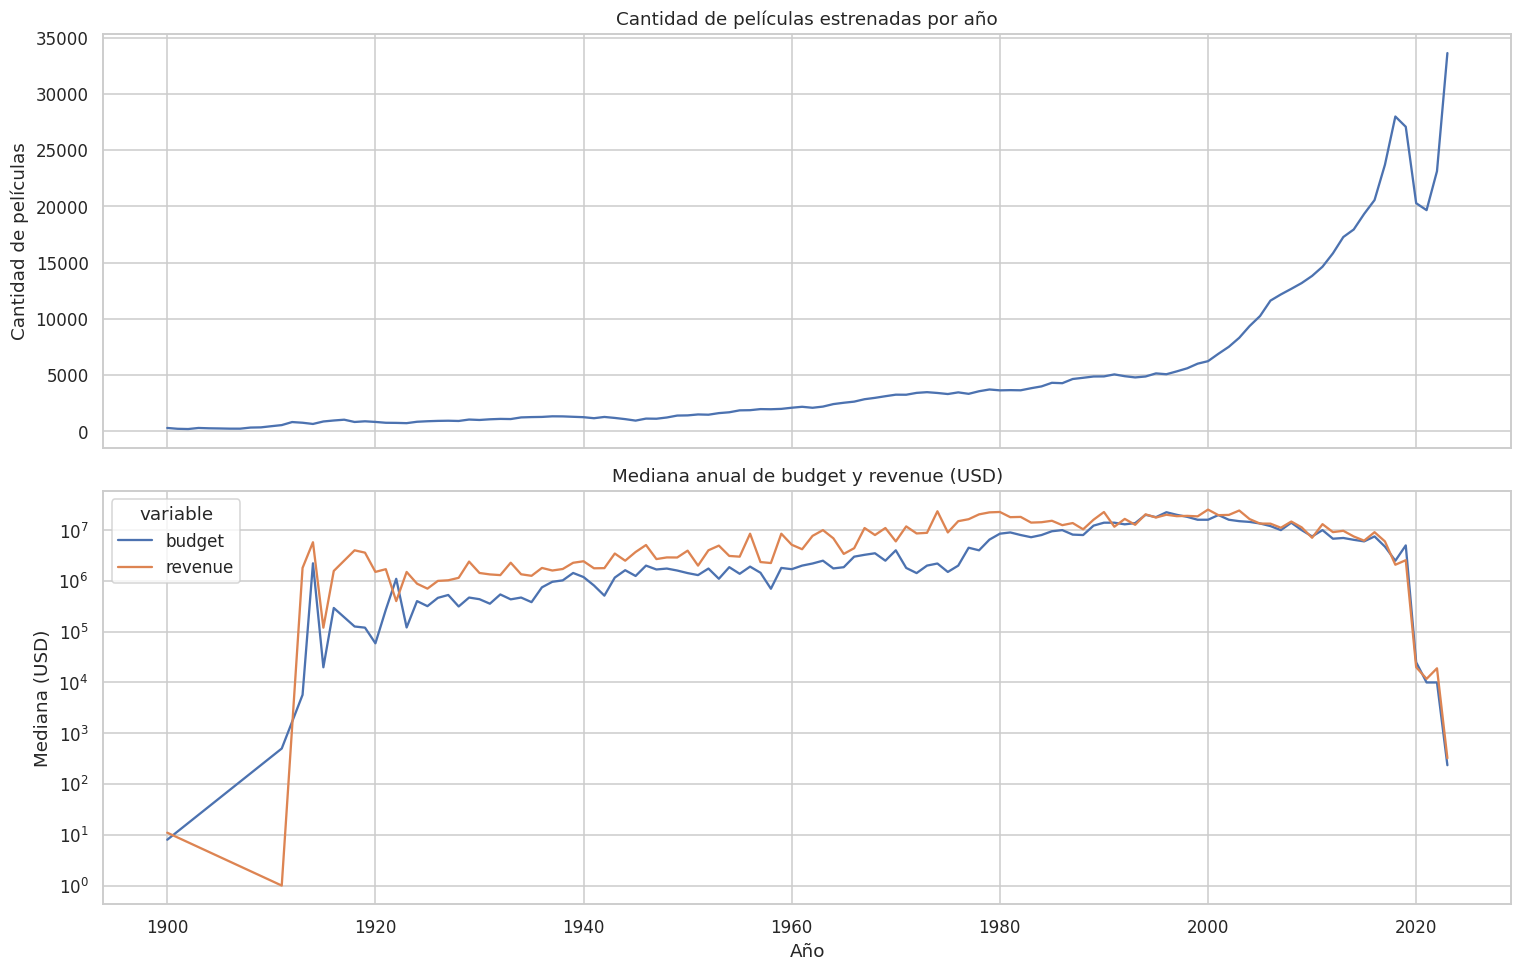

In [ ]:
global df
peliculas = df.copy()
peliculas = peliculas.dropna(subset=["release_date"])
peliculas["release_year"] = peliculas["release_date"].dt.year

# Filtro de años válidos (ANTES de cualquier agregación)
ANIO_MIN, ANIO_MAX = 1900, 2023
peliculas = peliculas[peliculas["release_year"].between(ANIO_MIN, ANIO_MAX)]

# A. Volumen por año (ya sobre datos filtrados)
peliculas_por_anio = peliculas.groupby("release_year").size().reset_index(name="movie_count")

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
sns.lineplot(data=peliculas_por_anio, x="release_year", y="movie_count", ax=axes[0])
axes[0].set_title("Cantidad de películas estrenadas por año")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Cantidad de películas")

# B. Mediana budget/revenue por año (filtrando ceros centinela)
peliculas_dinero = peliculas[(peliculas["budget"] > 0) & (peliculas["revenue"] > 0)].copy()

medianas_dinero = peliculas_dinero.groupby("release_year")[["budget","revenue"]].median().reset_index()
medianas_largo = medianas_dinero.melt(id_vars="release_year", value_vars=["budget","revenue"],
                                       var_name="variable", value_name="mediana")
sns.lineplot(data=medianas_largo, x="release_year", y="mediana", hue="variable", ax=axes[1])
axes[1].set_title("Mediana anual de budget y revenue (USD)")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Mediana (USD)")
axes[1].set_yscale("log")

plt.tight_layout(); plt.show()

**Storytelling.** El volumen de registros cambia fuertemente por año y no debe interpretarse como producción cinematográfica real sin considerar la cobertura del catálogo. Las medianas de `budget`/`revenue` solo son comparables en años con suficiente cobertura y datos financieros observados.

> TODO: formalizar sensibilidad de los resultados a distintos cortes temporales y reportar intervalos de confianza por año.

## 3. Análisis univariado

### Estadística descriptiva, asimetría y curtosis

In [ ]:
num_foco = ["vote_average", "runtime", "budget", "revenue", "vote_count", "popularity"]

df[num_foco].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
vote_average,361022.0,6.2,2.0,0.0,5.0,6.0,7.2,1.000000e+01
runtime,686974.0,65.6,66.3,1.0,15.0,69.0,95.0,1.440000e+04
budget,72684.0,4579735.5,22701503.5,1.0,150.0,2500.0,200000.0,1.000000e+09
revenue,23526.0,38329591.8,152647003.4,1.0,1571.0,1000000.0,14855428.5,5.000000e+09
vote_count,1008691.0,21.3,338.0,0.0,0.0,0.0,1.0,3.449500e+04
popularity,1008691.0,1.1,8.0,0.0,0.0,0.6,0.8,2.994400e+03


In [ ]:
momentos = pd.DataFrame({
    "media": df[num_foco].mean(),
    "mediana": df[num_foco].median(),
    "desv_std": df[num_foco].std(),
    "skew": df[num_foco].skew(),
    "kurtosis": df[num_foco].kurtosis(),
}).round(2)
momentos

,media,mediana,desv_std,skew,kurtosis
vote_average,6.16,6.0,2.030000e+00,-0.16,0.26
runtime,65.59,69.0,6.634000e+01,43.40,7878.98
budget,4579735.53,2500.0,2.270150e+07,14.88,401.38
revenue,38329591.78,1000000.0,1.526470e+08,12.79,283.33
vote_count,21.28,0.0,3.380300e+02,38.61,2039.96
popularity,1.07,0.6,7.990000e+00,166.17,45039.95


**Interpretación.** La comparación media–mediana y los coeficientes de asimetría/curtosis muestran colas derechas muy marcadas en montos, conteos y popularidad. `vote_average` está acotada entre 0 y 10 y tiene un comportamiento distinto al de variables monetarias.

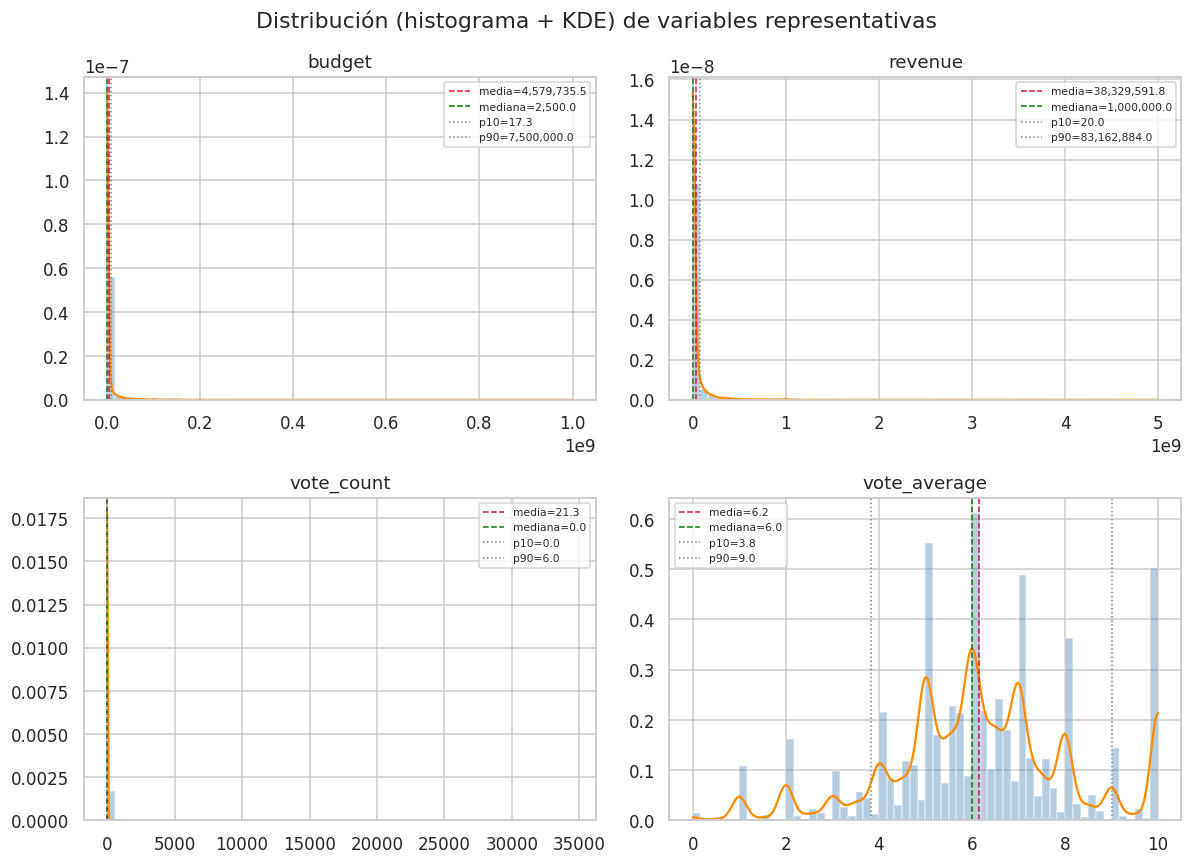

In [ ]:
from scipy.stats import gaussian_kde

vars_hist = ["budget", "revenue", "vote_count", "vote_average"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, col in zip(axes.ravel(), vars_hist):
    serie = df[col].dropna()

    ax.hist(serie, bins=60, density=True, alpha=0.4, color="steelblue")
    kde = gaussian_kde(serie)
    xs = np.linspace(serie.min(), serie.max(), 300)
    ax.plot(xs, kde(xs), color="darkorange", lw=1.5)

    media, mediana = serie.mean(), serie.median()
    p10, p90 = serie.quantile([0.1, 0.9])
    ax.axvline(media, color="crimson", ls="--", lw=1, label=f"media={media:,.1f}")
    ax.axvline(mediana, color="green", ls="--", lw=1, label=f"mediana={mediana:,.1f}")
    ax.axvline(p10, color="gray", ls=":", lw=1, label=f"p10={p10:,.1f}")
    ax.axvline(p90, color="gray", ls=":", lw=1, label=f"p90={p90:,.1f}")
    ax.set_title(col)
    ax.legend(fontsize=7)

fig.suptitle("Distribución (histograma + KDE) de variables representativas")
plt.tight_layout()
plt.show()

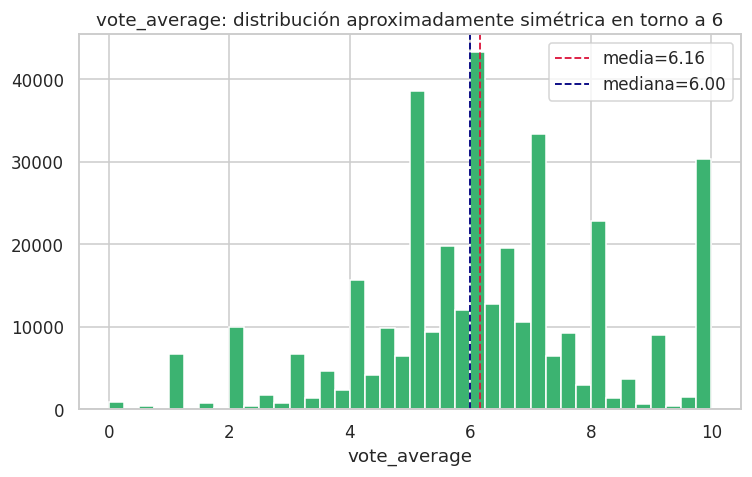

In [ ]:
serie_va = df["vote_average"].dropna()
plt.figure(figsize=(7, 4.5))
plt.hist(serie_va, bins=40, color="mediumseagreen", edgecolor="white")
plt.axvline(serie_va.mean(), color="crimson", ls="--", lw=1.2, label=f"media={serie_va.mean():.2f}")
plt.axvline(serie_va.median(), color="navy", ls="--", lw=1.2, label=f"mediana={serie_va.median():.2f}")
plt.title("vote_average: distribución aproximadamente simétrica en torno a 6")
plt.xlabel("vote_average")
plt.legend()
plt.tight_layout()
plt.show()

**Storytelling de las distribuciones.** Las variables financieras, `vote_count` y `popularity` concentran muchos valores bajos y pocos valores extremos. Por eso el borrador utiliza escalas logarítmicas en gráficos bivariados y `log1p` para `vote_count` durante el preprocesamiento.

> TODO: agregar pruebas de normalidad (por ejemplo, Shapiro–Wilk sobre una muestra o Anderson–Darling) y reportar que con n muy grande la significación no equivale a relevancia práctica.

### Variables categóricas y multivaluadas

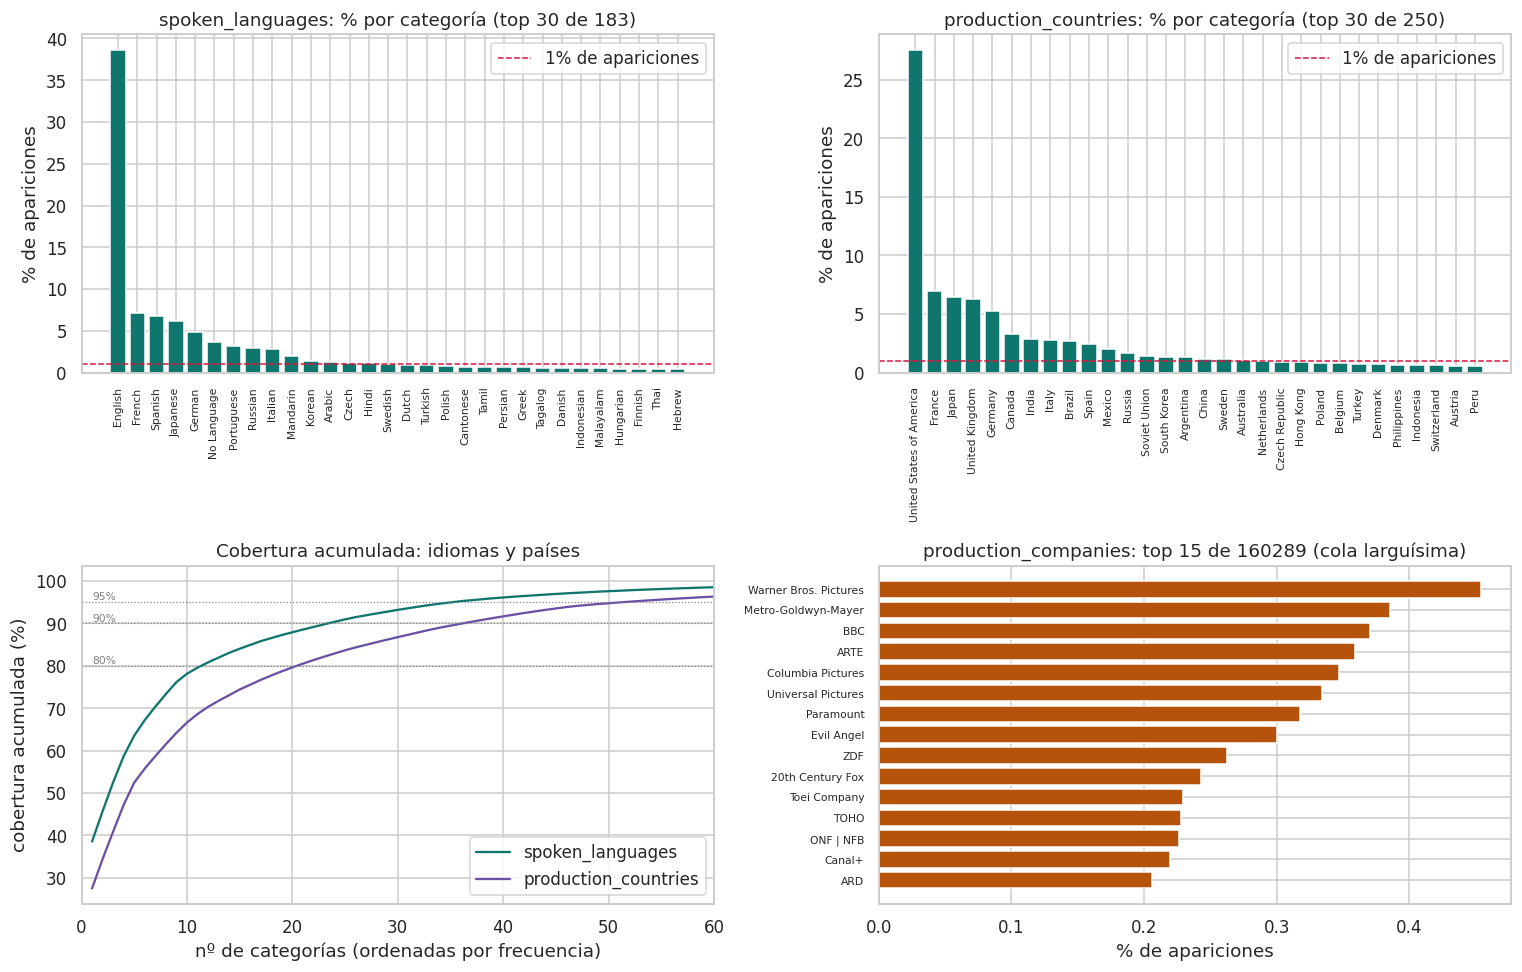

In [ ]:
# Frecuencia de categorías (sobre el total). Las multivaluadas se separan por ", ".
def _tokens(col):
    s = df[col].dropna().str.split(", ").explode().str.strip()
    return s[s != ""]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# % por categoría (top 30) con línea de referencia en 1%
for ax, col in [(axes[0, 0], "spoken_languages"), (axes[0, 1], "production_countries")]:
    vc = _tokens(col).value_counts()
    top = (vc / vc.sum() * 100).head(30)
    ax.bar(range(len(top)), top.values, color="#0F766E")
    ax.axhline(1.0, color="crimson", ls="--", lw=1, label="1% de apariciones")
    ax.set_xticks(range(len(top)))
    ax.set_xticklabels(top.index, rotation=90, fontsize=7)
    ax.set_ylabel("% de apariciones")
    ax.set_title(f"{col}: % por categoría (top 30 de {len(vc)})")
    ax.legend()

# curva de cobertura acumulada
ax = axes[1, 0]
for col, color in [("spoken_languages", "#0F766E"), ("production_countries", "#6a51a3")]:
    vc = _tokens(col).value_counts()
    cum = vc.cumsum() / vc.sum() * 100
    ax.plot(range(1, len(cum) + 1), cum.values, label=col, color=color)
for thr in (80, 90, 95):
    ax.axhline(thr, color="grey", ls=":", lw=0.8)
    ax.text(1, thr + 0.5, f"{thr}%", fontsize=7, color="grey")
ax.set_xlim(0, 60)
ax.set_xlabel("nº de categorías (ordenadas por frecuencia)")
ax.set_ylabel("cobertura acumulada (%)")
ax.set_title("Cobertura acumulada: idiomas y países")
ax.legend()

# production_companies: top 15 -> evidencia la cola larguísima
ax = axes[1, 1]
vc = _tokens("production_companies").value_counts()
top = (vc / vc.sum() * 100).head(15)
ax.barh(range(len(top))[::-1], top.values, color="#b45309")
ax.set_yticks(range(len(top))[::-1])
ax.set_yticklabels(top.index, fontsize=7)
ax.set_xlabel("% de apariciones")
ax.set_title(f"production_companies: top 15 de {len(vc)} (cola larguísima)")

plt.tight_layout()
plt.show()

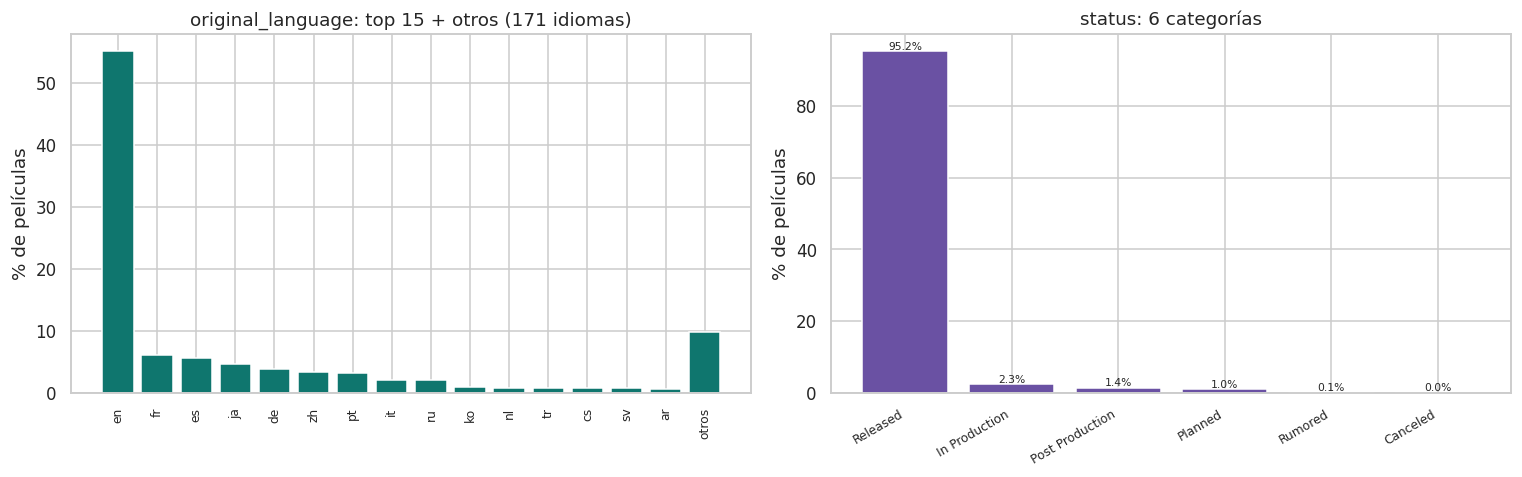

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# original_language: top 15 + "otros"
vc = df["original_language"].value_counts()
pct = vc / vc.sum() * 100
top = pct.head(15)
labels = list(top.index) + ["otros"]
vals = list(top.values) + [pct.iloc[15:].sum()]
axes[0].bar(range(len(labels)), vals, color="#0F766E")
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=90, fontsize=8)
axes[0].set_ylabel("% de películas")
axes[0].set_title(f"original_language: top 15 + otros ({len(vc)} idiomas)")

# status: 6 categorías
pct = df["status"].value_counts() / len(df) * 100
axes[1].bar(range(len(pct)), pct.values, color="#6a51a3")
axes[1].set_xticks(range(len(pct)))
axes[1].set_xticklabels(pct.index, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("% de películas")
axes[1].set_title("status: 6 categorías")
for i, v in enumerate(pct.values):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

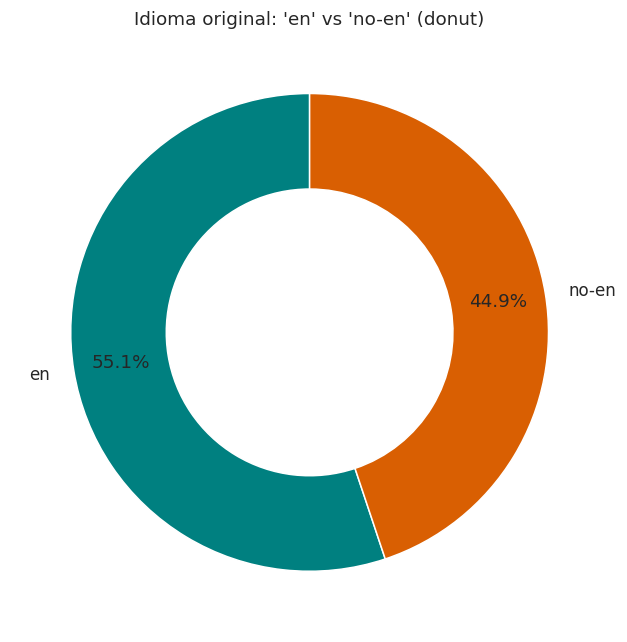

In [ ]:
# --- Binarización de 'original_language' ---
df["original_language_bin"] = np.where(df["original_language"] == "en", "en", "no-en")
lang_bin_counts = df["original_language_bin"].value_counts()

# --- Donut de original_language_bin ---
fig, ax = plt.subplots(figsize=(6, 6))

colors_lang_bin = ["teal", "#d95f02"]

wedges, texts, autotexts = ax.pie(
    lang_bin_counts.values,
    labels=lang_bin_counts.index,
    autopct="%1.1f%%",
    colors=colors_lang_bin,
    startangle=90,
    pctdistance=0.8,
    wedgeprops=dict(width=0.4),
)
ax.set_title("Idioma original: 'en' vs 'no-en' (donut)")

plt.tight_layout()
plt.show()

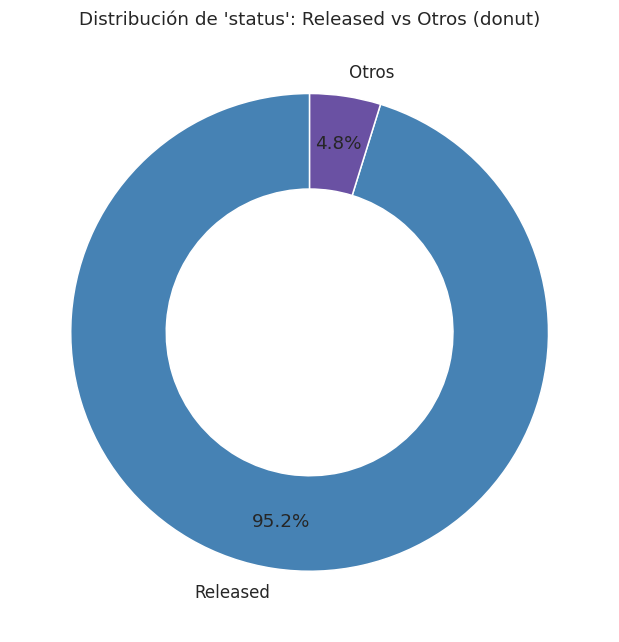

In [ ]:
# --- Simplificación de 'status' a 2 categorías ---
df["status_bin"] = np.where(df["status"] == "Released", "Released", "Otros")
status_bin_counts = df["status_bin"].value_counts()

# --- Donut de status_bin ---
fig, ax = plt.subplots(figsize=(6, 6))

colors_status_bin = ["steelblue", "#6a51a3"]

wedges, texts, autotexts = ax.pie(
    status_bin_counts.values,
    labels=status_bin_counts.index,
    autopct="%1.1f%%",
    colors=colors_status_bin,
    startangle=90,
    pctdistance=0.8,
    wedgeprops=dict(width=0.4),
)
ax.set_title("Distribución de 'status': Released vs Otros (donut)")

plt.tight_layout()
plt.show()

**Interpretación.** Idiomas, estados y campos multivaluados presentan concentración en pocas categorías y colas largas. La binarización `en`/`no-en` y `Released`/`Otros` se conserva como feature engineering exploratorio, pero su justificación depende del objetivo del modelo.

## 4. Análisis bivariado y multivariado

### Géneros

In [ ]:
genre_long = (df[["id", "genres"]].dropna(subset=["genres"])
              .assign(genre=lambda d: d["genres"].str.split(", "))
              .explode("genre"))
genre_long["genre"] = genre_long["genre"].str.strip()
genre_long = genre_long[genre_long["genre"] != ""]

print("géneros únicos:", genre_long["genre"].nunique())
print("películas con género informado:", genre_long["id"].nunique())

géneros únicos: 19
películas con género informado: 558497


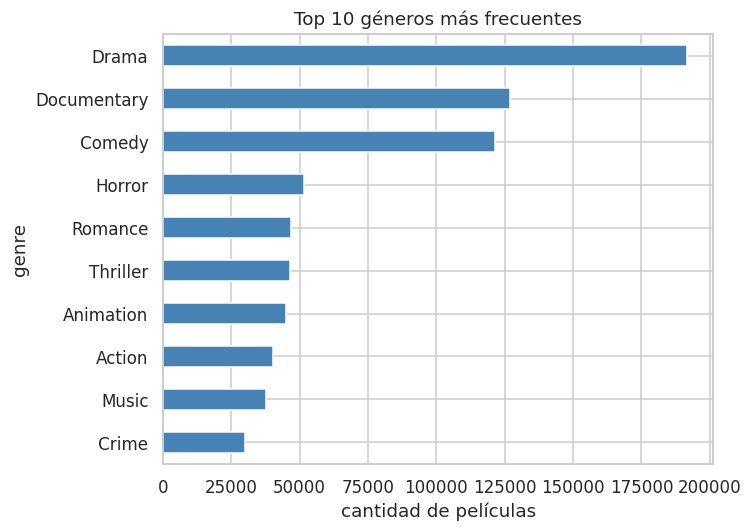

In [ ]:
top10_generos = genre_long["genre"].value_counts().head(10)

plt.figure(figsize=(7, 5))
top10_generos.sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("cantidad de películas")
plt.title("Top 10 géneros más frecuentes")
plt.tight_layout()
plt.show()

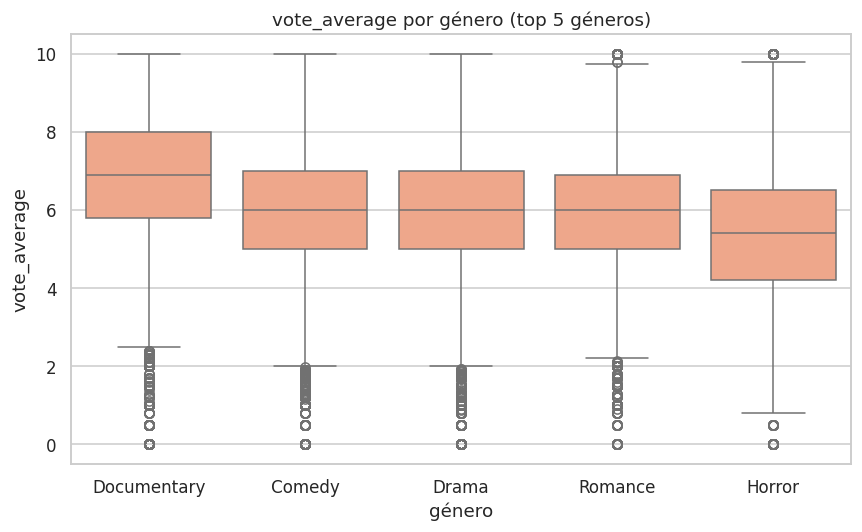

In [ ]:
top5_generos = top10_generos.head(5).index.tolist()

genero_rating = (genre_long[genre_long["genre"].isin(top5_generos)]
                  .merge(df[["id", "vote_average"]], on="id", how="left")
                  .dropna(subset=["vote_average"]))

plt.figure(figsize=(8, 5))
orden = genero_rating.groupby("genre")["vote_average"].median().sort_values(ascending=False).index
sns.boxplot(data=genero_rating, x="genre", y="vote_average", order=orden, color="lightsalmon")
plt.xlabel("género")
plt.ylabel("vote_average")
plt.title("vote_average por género (top 5 géneros)")
plt.tight_layout()
plt.show()

**Storytelling.** El gráfico de frecuencias muestra los géneros más representados; el boxplot permite comparar la distribución de `vote_average` entre los cinco géneros principales, sin interpretar diferencias como causalidad. La unidad de conteo es película–género, por lo que una película puede contribuir a más de una categoría.

### Correlaciones y relaciones numéricas

In [ ]:
corr_pearson = df[num_foco].corr(method="pearson")
corr_spearman = df[num_foco].corr(method="spearman")
corr_pearson.round(2)

,vote_average,runtime,budget,revenue,vote_count,popularity
vote_average,1.00,0.03,-0.02,0.08,0.04,0.01
runtime,0.03,1.00,0.26,0.14,0.05,0.06
budget,-0.02,0.26,1.00,0.56,0.48,0.23
revenue,0.08,0.14,0.56,1.00,0.52,0.18
vote_count,0.04,0.05,0.48,0.52,1.00,0.26
popularity,0.01,0.06,0.23,0.18,0.26,1.00


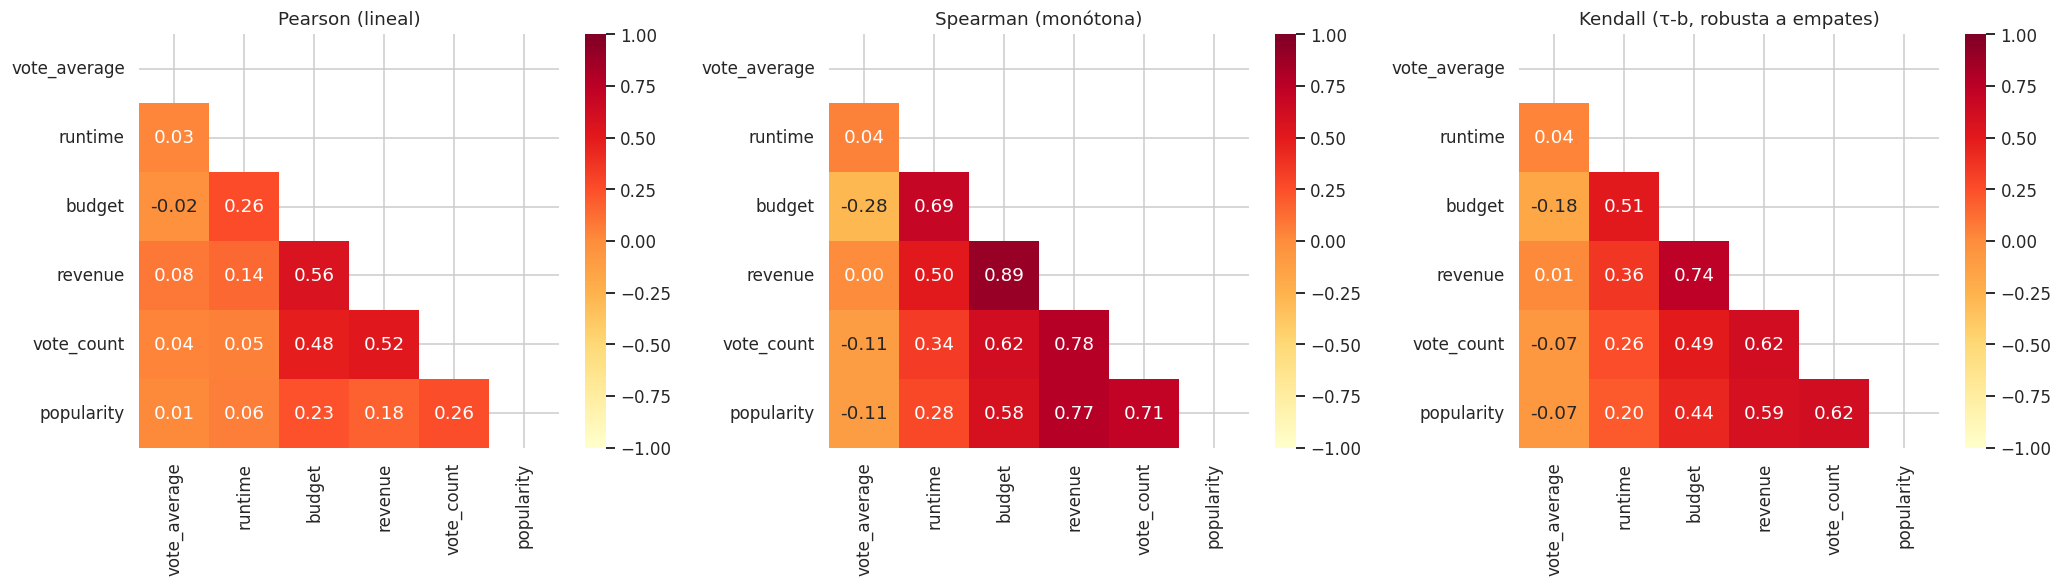

In [ ]:
corr_kendall = df[num_foco].corr(method="kendall")

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="YlOrRd", vmin=-1, vmax=1, mask=mask, ax=axes[0])
axes[0].set_title("Pearson (lineal)")

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="YlOrRd", vmin=-1, vmax=1, mask=mask, ax=axes[1])
axes[1].set_title("Spearman (monótona)")

sns.heatmap(corr_kendall, annot=True, fmt=".2f", cmap="YlOrRd", vmin=-1, vmax=1, mask=mask, ax=axes[2])
axes[2].set_title("Kendall (τ-b, robusta a empates)")

plt.tight_layout()
plt.show()

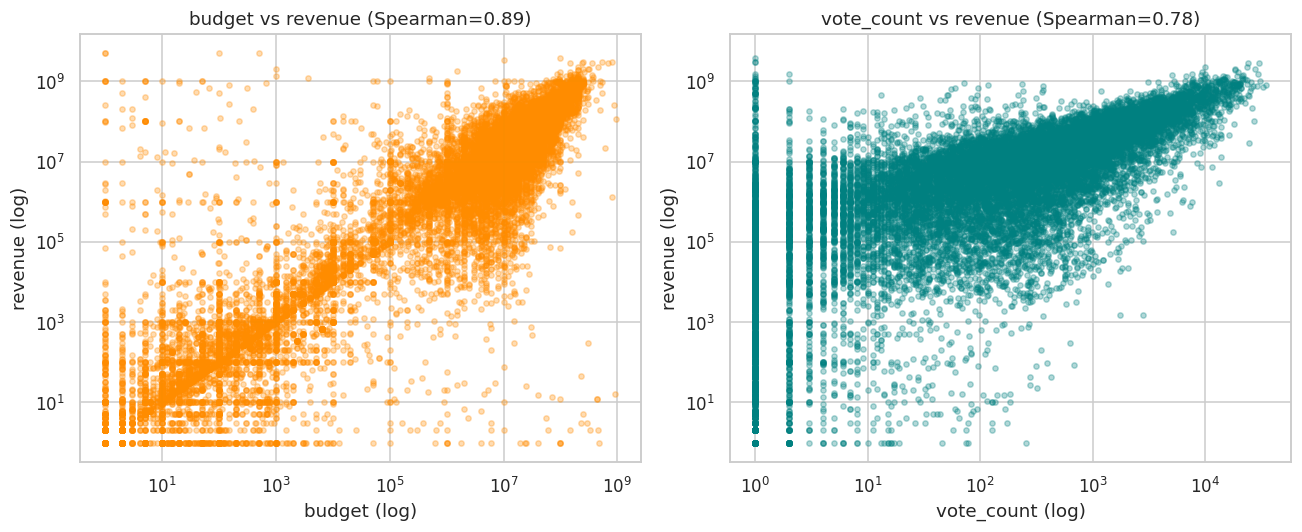

In [ ]:
from scipy.stats import spearmanr

muestra_br = df[["budget", "revenue"]].dropna()
rho_br, _ = spearmanr(muestra_br["budget"], muestra_br["revenue"])

muestra_vr = df[["vote_count", "revenue"]].dropna()
rho_vr, _ = spearmanr(muestra_vr["vote_count"], muestra_vr["revenue"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(muestra_br["budget"], muestra_br["revenue"], alpha=0.3, s=12, color="darkorange")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("budget (log)"); axes[0].set_ylabel("revenue (log)")
axes[0].set_title(f"budget vs revenue (Spearman={rho_br:.2f})")

axes[1].scatter(muestra_vr["vote_count"], muestra_vr["revenue"], alpha=0.3, s=12, color="teal")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("vote_count (log)"); axes[1].set_ylabel("revenue (log)")
axes[1].set_title(f"vote_count vs revenue (Spearman={rho_vr:.2f})")
plt.tight_layout()
plt.show()

**Interpretación.** Pearson resume asociación lineal; Spearman y Kendall son más adecuados ante asimetría, empates y relaciones monotónicas. En particular, una diferencia entre Pearson y Spearman para `budget`–`revenue` es consistente con colas extremas. Los scatterplots usan escala log para hacer visible la masa central; no prueban causalidad.

### Asociaciones entre categóricas y numéricas

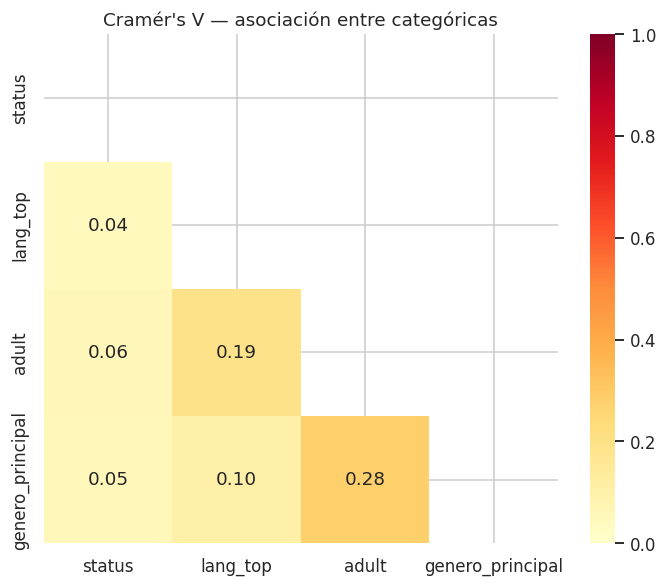

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    x = x.astype(str)
    y = y.astype(str)
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla, correction=False)[0]
    n = tabla.sum().sum()
    phi2 = chi2 / n
    r, k = tabla.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2_corr / min(k_corr - 1, r_corr - 1))

# --- preparar categóricas auxiliares (no modifican df original) ---
top10_lang = ['en', 'fr', 'es', 'ja', 'de', 'zh', 'pt', 'it', 'ru', 'ko']
lang_top = df["original_language"].astype(str).where(
    df["original_language"].astype(str).isin(top10_lang), "otros"
)
genero_principal = df["genres"].astype(str).str.split(", ").str[0]
adult_cat = df["adult"].astype(str)
status_cat = df["status"].astype(str)

cat_vars = pd.DataFrame({
    "status": status_cat,
    "lang_top": lang_top,
    "adult": adult_cat,
    "genero_principal": genero_principal
})

cols_cat = cat_vars.columns
cramers_matrix = pd.DataFrame(index=cols_cat, columns=cols_cat, dtype=float)

for c1 in cols_cat:
    for c2 in cols_cat:
        mask_valid = cat_vars[c1].notna() & cat_vars[c2].notna()
        cramers_matrix.loc[c1, c2] = 1.0 if c1 == c2 else cramers_v(
            cat_vars.loc[mask_valid, c1], cat_vars.loc[mask_valid, c2]
        )

mask_cat = np.triu(np.ones_like(cramers_matrix, dtype=bool))
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, mask=mask_cat)
plt.title("Cramér's V — asociación entre categóricas")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import kruskal

def correlation_ratio(categorias, valores):
    df_tmp = pd.DataFrame({"cat": categorias, "val": valores}).dropna()
    medias_grupo = df_tmp.groupby("cat")["val"].mean()
    n_grupo = df_tmp.groupby("cat")["val"].size()
    media_total = df_tmp["val"].mean()
    ss_between = (n_grupo * (medias_grupo - media_total) ** 2).sum()
    ss_total = ((df_tmp["val"] - media_total) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan

def kruskal_safe(categorias, valores):
    df_tmp = pd.DataFrame({"cat": categorias, "val": valores}).dropna()
    grupos = [g["val"].values for _, g in df_tmp.groupby("cat") if len(g) > 0]
    if len(grupos) < 2:
        return np.nan, np.nan
    stat, p = kruskal(*grupos)
    return stat, p

resultados = []
for cat_name in cat_vars.columns:
    for num_name in num_foco:
        eta = correlation_ratio(cat_vars[cat_name], df[num_name])
        stat, p = kruskal_safe(cat_vars[cat_name], df[num_name])
        resultados.append({
            "categórica": cat_name,
            "numérica": num_name,
            "eta": round(eta, 3) if pd.notna(eta) else np.nan,
            "kruskal_H": round(stat, 1) if pd.notna(stat) else np.nan,
            "p_valor": f"{p:.2e}" if pd.notna(p) else np.nan
        })

tabla_eta = pd.DataFrame(resultados).sort_values("eta", ascending=False).reset_index(drop=True)
tabla_eta

,categórica,numérica,eta,kruskal_H,p_valor
0,adult,runtime,0.279,76071.3,0.00e+00
1,genero_principal,budget,0.230,9632.1,0.00e+00
2,genero_principal,vote_average,0.196,17073.0,0.00e+00
3,genero_principal,runtime,0.193,60171.5,0.00e+00
4,genero_principal,revenue,0.185,5229.7,0.00e+00
5,adult,vote_average,0.150,9437.7,0.00e+00
6,lang_top,revenue,0.125,1598.1,0.00e+00
7,genero_principal,popularity,0.119,287895.5,0.00e+00
8,lang_top,runtime,0.106,19597.5,0.00e+00
9,genero_principal,vote_count,0.104,220527.4,0.00e+00


In [ ]:
from scipy.stats import pointbiserialr

resultados_pb = []
for col in num_foco:
    mask_valid = df["adult"].notna() & df[col].notna()
    r, p = pointbiserialr(df.loc[mask_valid, "adult"].astype(int), df.loc[mask_valid, col])
    media_false = df.loc[mask_valid & (df["adult"] == False), col].mean()
    media_true = df.loc[mask_valid & (df["adult"] == True), col].mean()
    resultados_pb.append({
        "variable": col,
        "r_pointbiserial": round(r, 3),
        "p_valor": f"{p:.2e}",
        "media_adult_False": round(media_false, 2),
        "media_adult_True": round(media_true, 2)
    })

tabla_pb = pd.DataFrame(resultados_pb).sort_values("r_pointbiserial", key=abs, ascending=False)
tabla_pb

,variable,r_pointbiserial,p_valor,media_adult_False,media_adult_True
1,runtime,0.279,0.00e+00,59.22,119.22
0,vote_average,0.150,0.00e+00,6.08,7.38
5,popularity,-0.026,3.65e-145,1.14,0.44
4,vote_count,-0.020,7.08e-88,23.42,0.38
2,budget,-0.018,2.28e-06,4630041.91,1431031.61
3,revenue,-0.015,2.07e-02,38609618.87,19402862.62


**Storytelling.** Cramér’s V resume asociación entre categóricas; η y Kruskal–Wallis comparan grupos numéricos sin asumir normalidad; point-biserial resume `adult` frente a variables numéricas. Con más de un millón de registros, los p-valores pueden ser pequeños aun cuando el tamaño de efecto sea débil: se prioriza reportar magnitud.

## 5. Valores faltantes y outliers

### Diagnóstico de mecanismos de faltantes

In [ ]:
import missingno as msno
from scipy.stats import pearsonr, spearmanr, kendalltau, entropy, ttest_ind

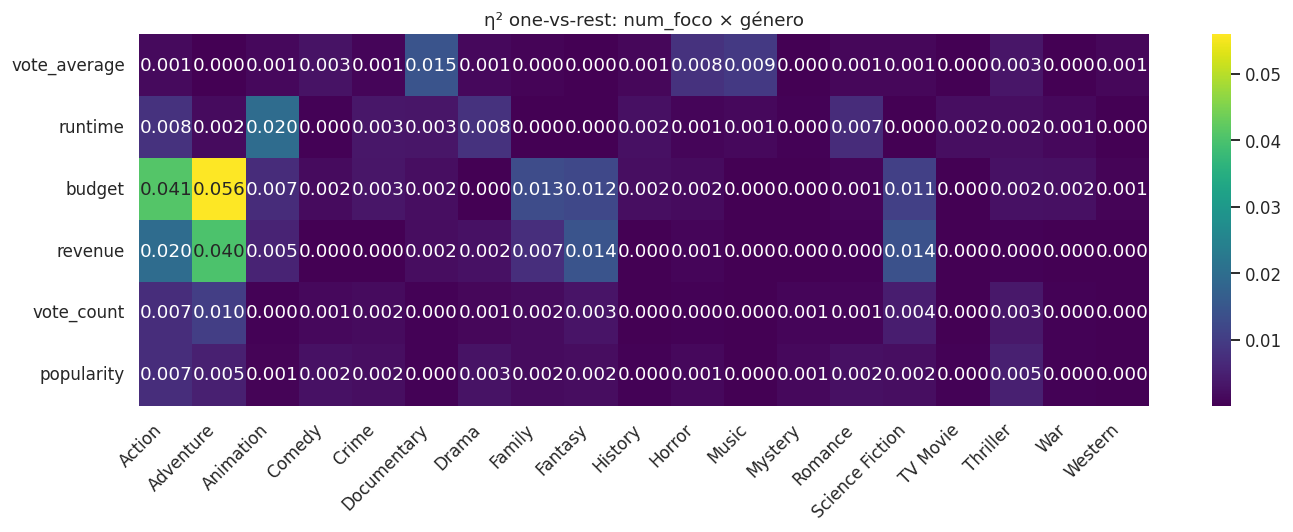

Escala interpretativa η² (Cohen): <0.01 trivial · 0.01-0.06 pequeño · 0.06-0.14 mediano · >0.14 grande.


In [ ]:
def eta_squared(categorias, valores):
    tmp = pd.DataFrame({"cat": categorias, "val": valores}).dropna()
    media_global = tmp["val"].mean()
    ss_total = ((tmp["val"] - media_global) ** 2).sum()
    if ss_total == 0:
        return np.nan
    ss_entre = tmp.groupby("cat")["val"].apply(lambda x: len(x) * (x.mean() - media_global) ** 2).sum()
    return ss_entre / ss_total

# indicadores binarios de género a nivel película (filtrando géneros con >=8 casos)
generos_ind = pd.get_dummies(genre_long.set_index("id")["genre"]).groupby("id").max()
generos_validos = generos_ind.columns[generos_ind.sum() >= 8]
generos_ind = generos_ind[generos_validos].astype(int)

df_gen = df.merge(generos_ind, left_on="id", right_index=True, how="left")
df_gen[generos_validos] = df_gen[generos_validos].fillna(0)

filas = []
for var in num_foco:
    filas.append({g: eta_squared(df_gen[g], df_gen[var]) for g in generos_validos})
eta_matrix = pd.DataFrame(filas, index=num_foco)

plt.figure(figsize=(13, 5))
sns.heatmap(eta_matrix, annot=True, fmt=".3f", cmap="viridis")
plt.title("η² one-vs-rest: num_foco × género")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Escala interpretativa η² (Cohen): <0.01 trivial · 0.01-0.06 pequeño · 0.06-0.14 mediano · >0.14 grande.")

In [ ]:
alpha = 0.05
pares = [("budget", "revenue"), ("budget", "vote_count"), ("revenue", "vote_count"),
         ("budget", "popularity"), ("revenue", "popularity")]
filas = []
for a, b in pares:
    sub = df[[a, b]].dropna()
    r_p, p_p = pearsonr(sub[a], sub[b])
    r_s, p_s = spearmanr(sub[a], sub[b])
    filas.append({"par": f"{a}–{b}", "n": len(sub),
                  "pearson_r": round(r_p, 3), "p_pearson": p_p,
                  "spearman_r": round(r_s, 3), "p_spearman": p_s,
                  "decisión (α=0.05)": "rechazo H0" if p_p < alpha else "no rechazo"})
tabla_tests = pd.DataFrame(filas)
print("H0: r = 0 (no hay asociación lineal)  |  H1: r ≠ 0")
tabla_tests

H0: r = 0 (no hay asociación lineal)  |  H1: r ≠ 0


,par,n,pearson_r,p_pearson,spearman_r,p_spearman,decisión (α=0.05)
0,budget–revenue,16906,0.563,0.000000e+00,0.891,0.0,rechazo H0
1,budget–vote_count,72684,0.481,0.000000e+00,0.617,0.0,rechazo H0
2,revenue–vote_count,23526,0.522,0.000000e+00,0.780,0.0,rechazo H0
3,budget–popularity,72684,0.235,0.000000e+00,0.582,0.0,rechazo H0
4,revenue–popularity,23526,0.177,1.510217e-164,0.770,0.0,rechazo H0


In [ ]:
print("H0: la media de vote_average es igual dentro y fuera del género | H1: difieren")
# t-test in-vs-out del género con mayor η² sobre vote_average
genero_top_va = eta_matrix.loc["vote_average"].idxmax()
grupo_in = df_gen.loc[df_gen[genero_top_va] == 1, "vote_average"].dropna()
grupo_out = df_gen.loc[df_gen[genero_top_va] == 0, "vote_average"].dropna()
t_stat, p_val = ttest_ind(grupo_in, grupo_out, equal_var=False)

print(f"Género más asociado a vote_average (η² máx): {genero_top_va} (η²={eta_matrix.loc['vote_average', genero_top_va]:.4f})")
print(f"t = {t_stat:.2f}, p = {p_val:.3g}")
print(f"media in={grupo_in.mean():.2f} (n={len(grupo_in)}) | media out={grupo_out.mean():.2f} (n={len(grupo_out)})")

H0: la media de vote_average es igual dentro y fuera del género | H1: difieren
Género más asociado a vote_average (η² máx): Documentary (η²=0.0146)
t = 74.46, p = 0
media in=6.76 (n=50864) | media out=6.06 (n=310158)


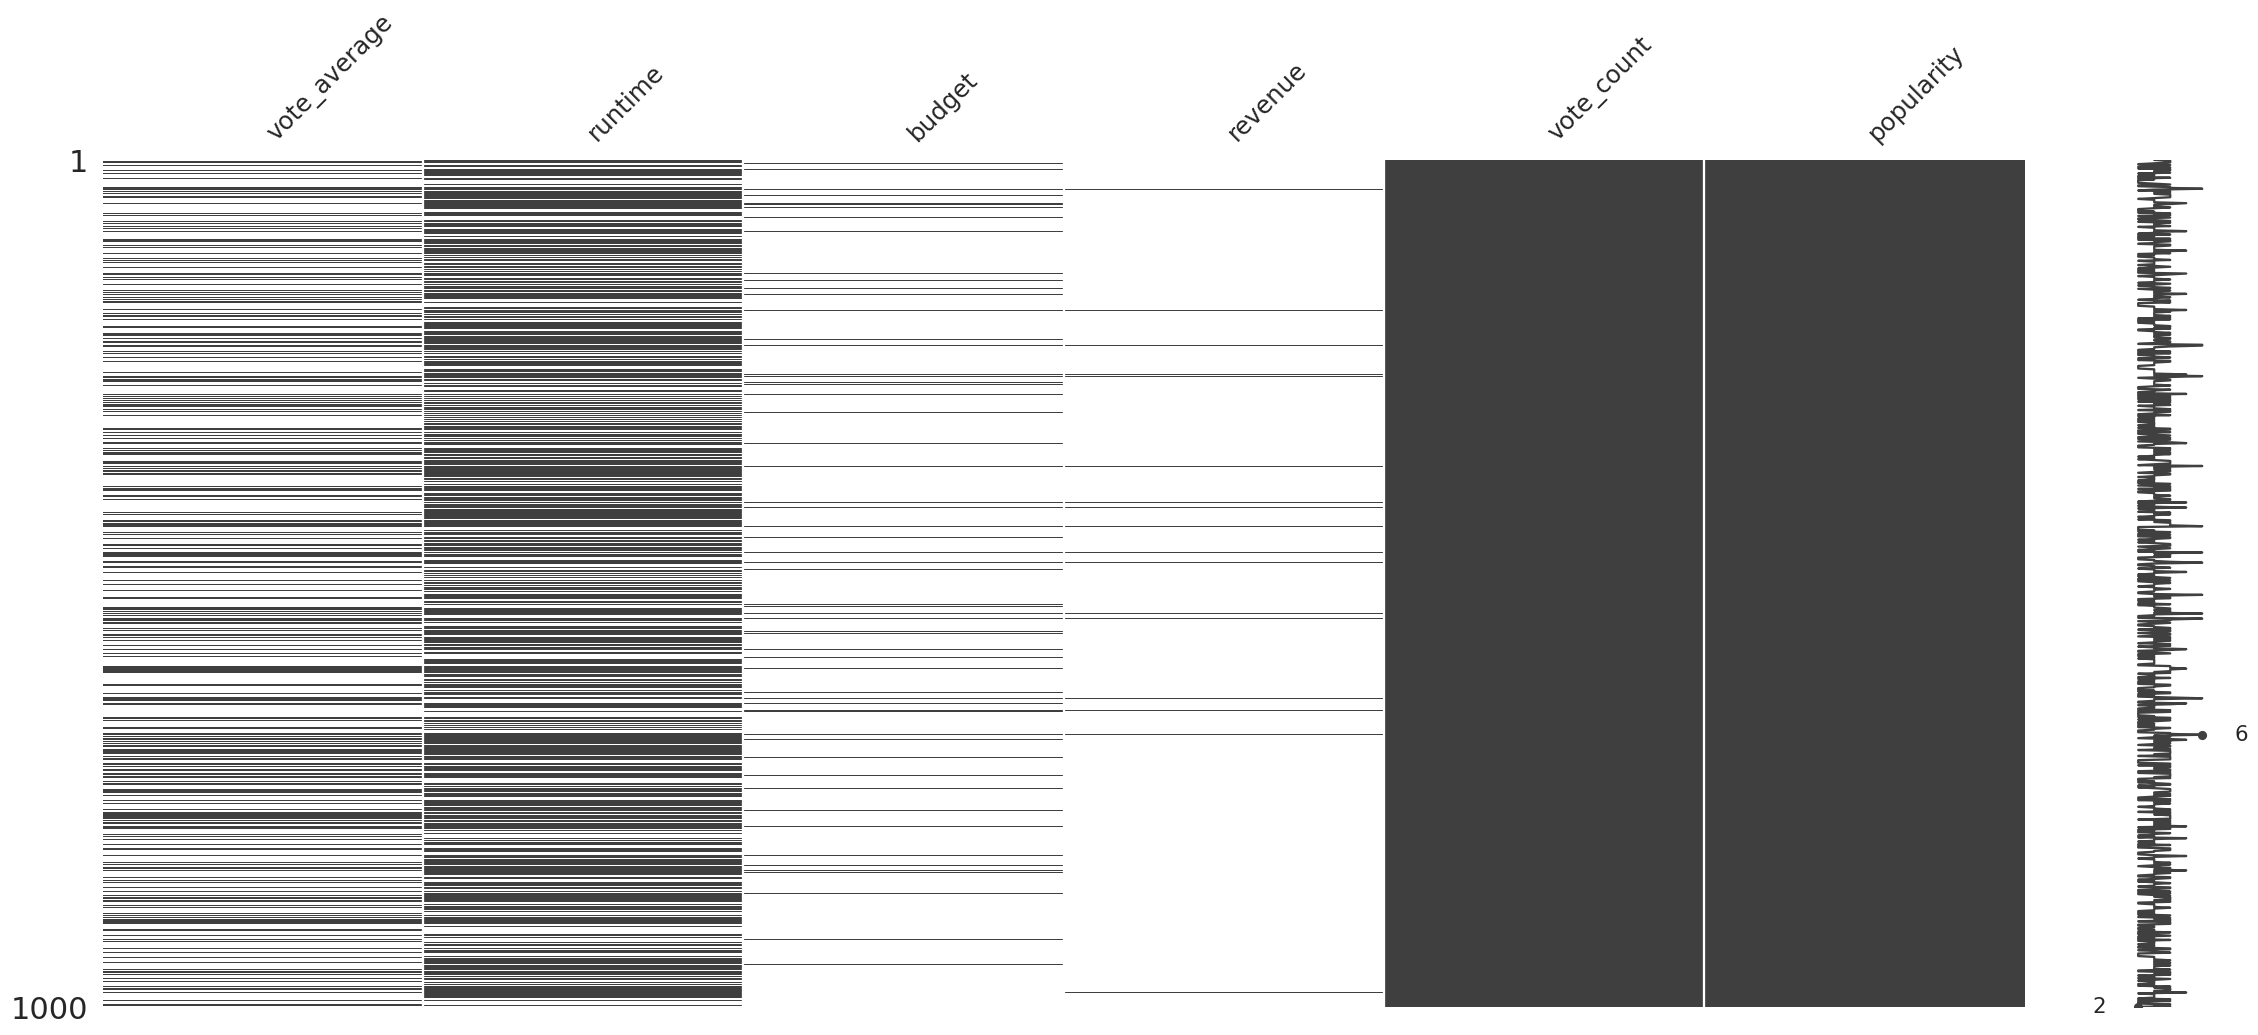

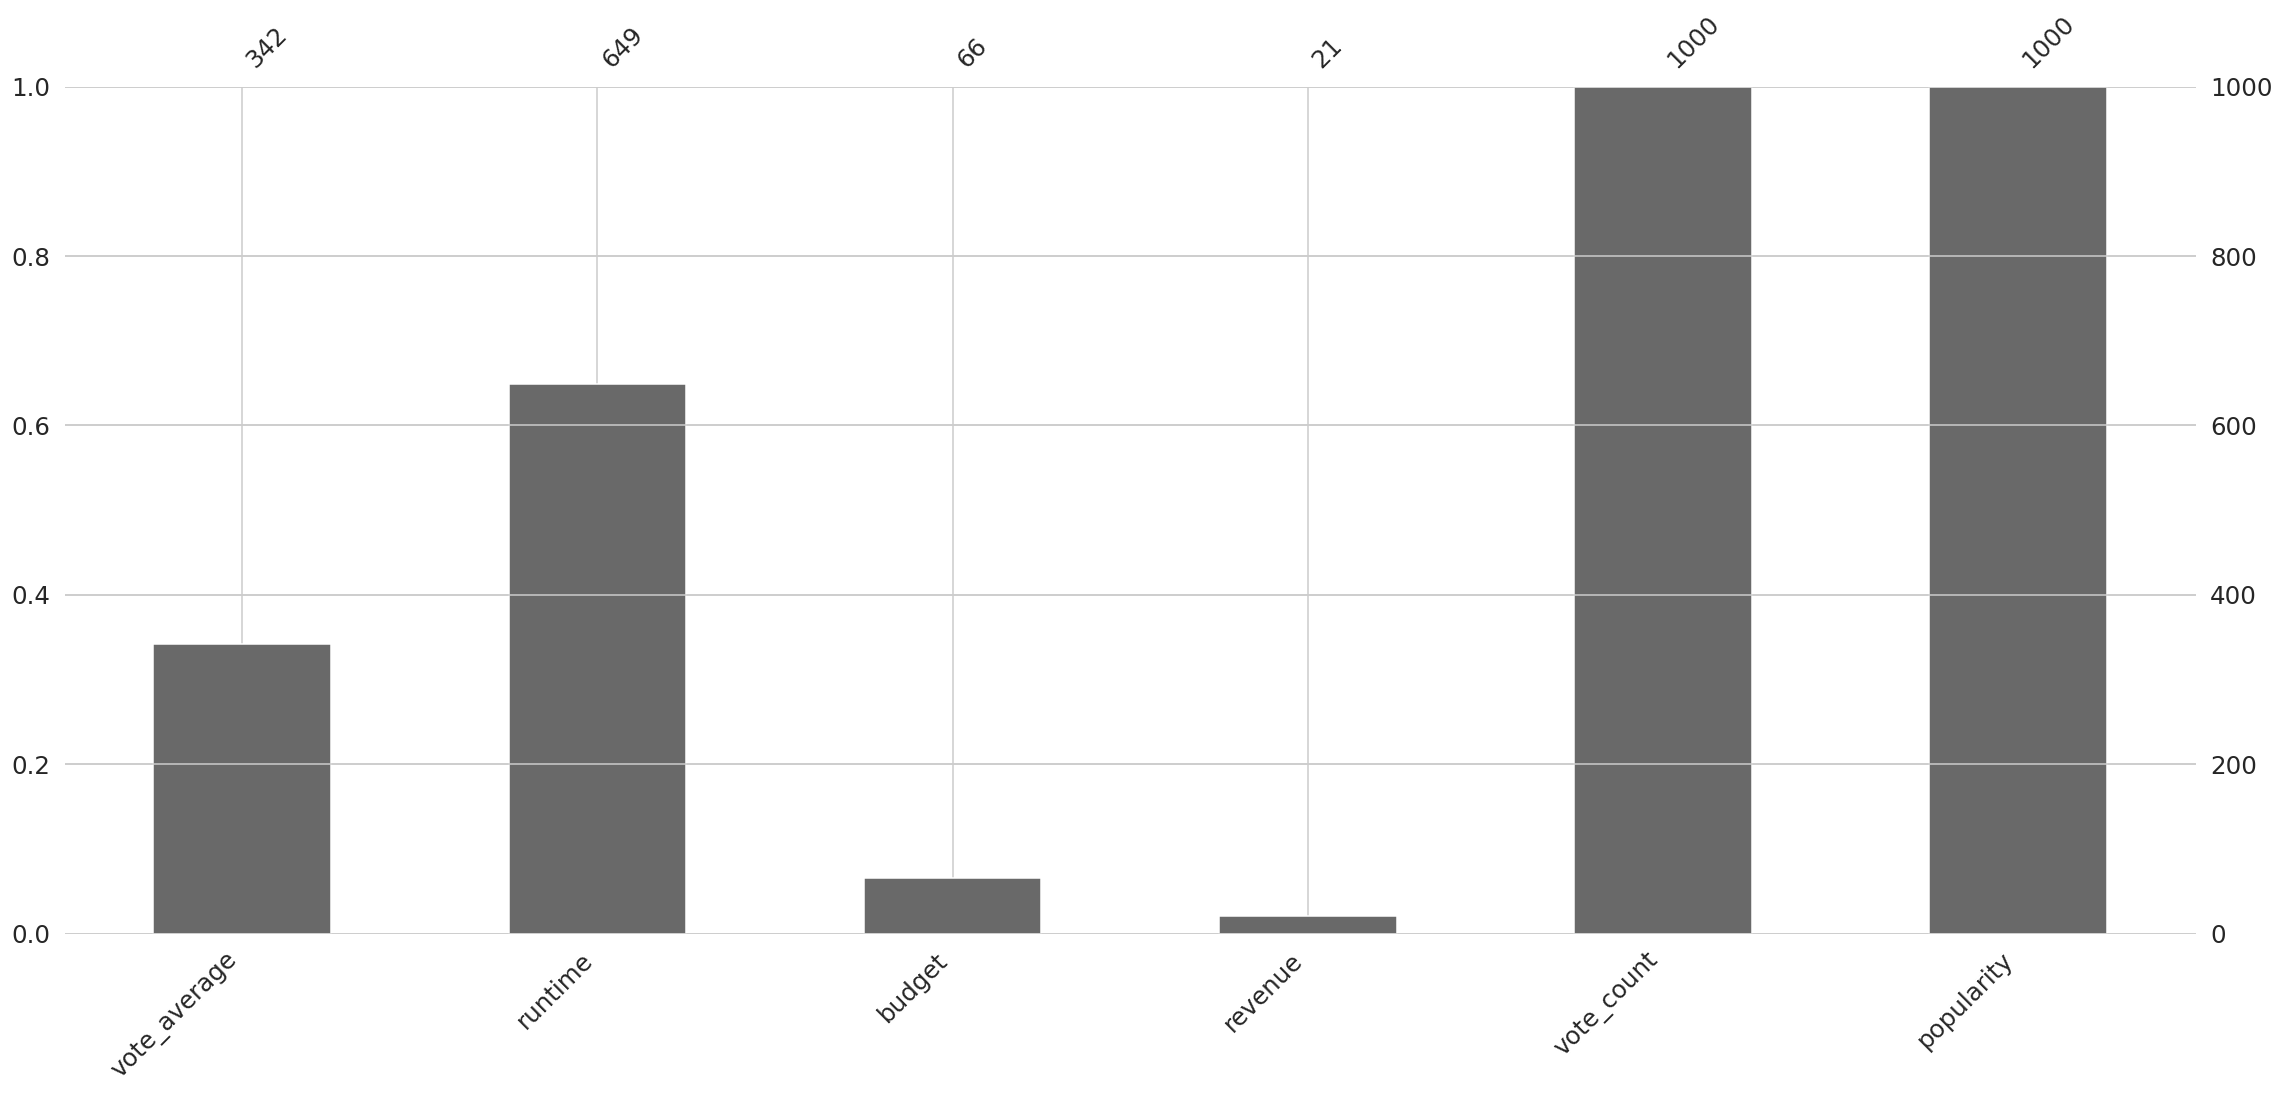

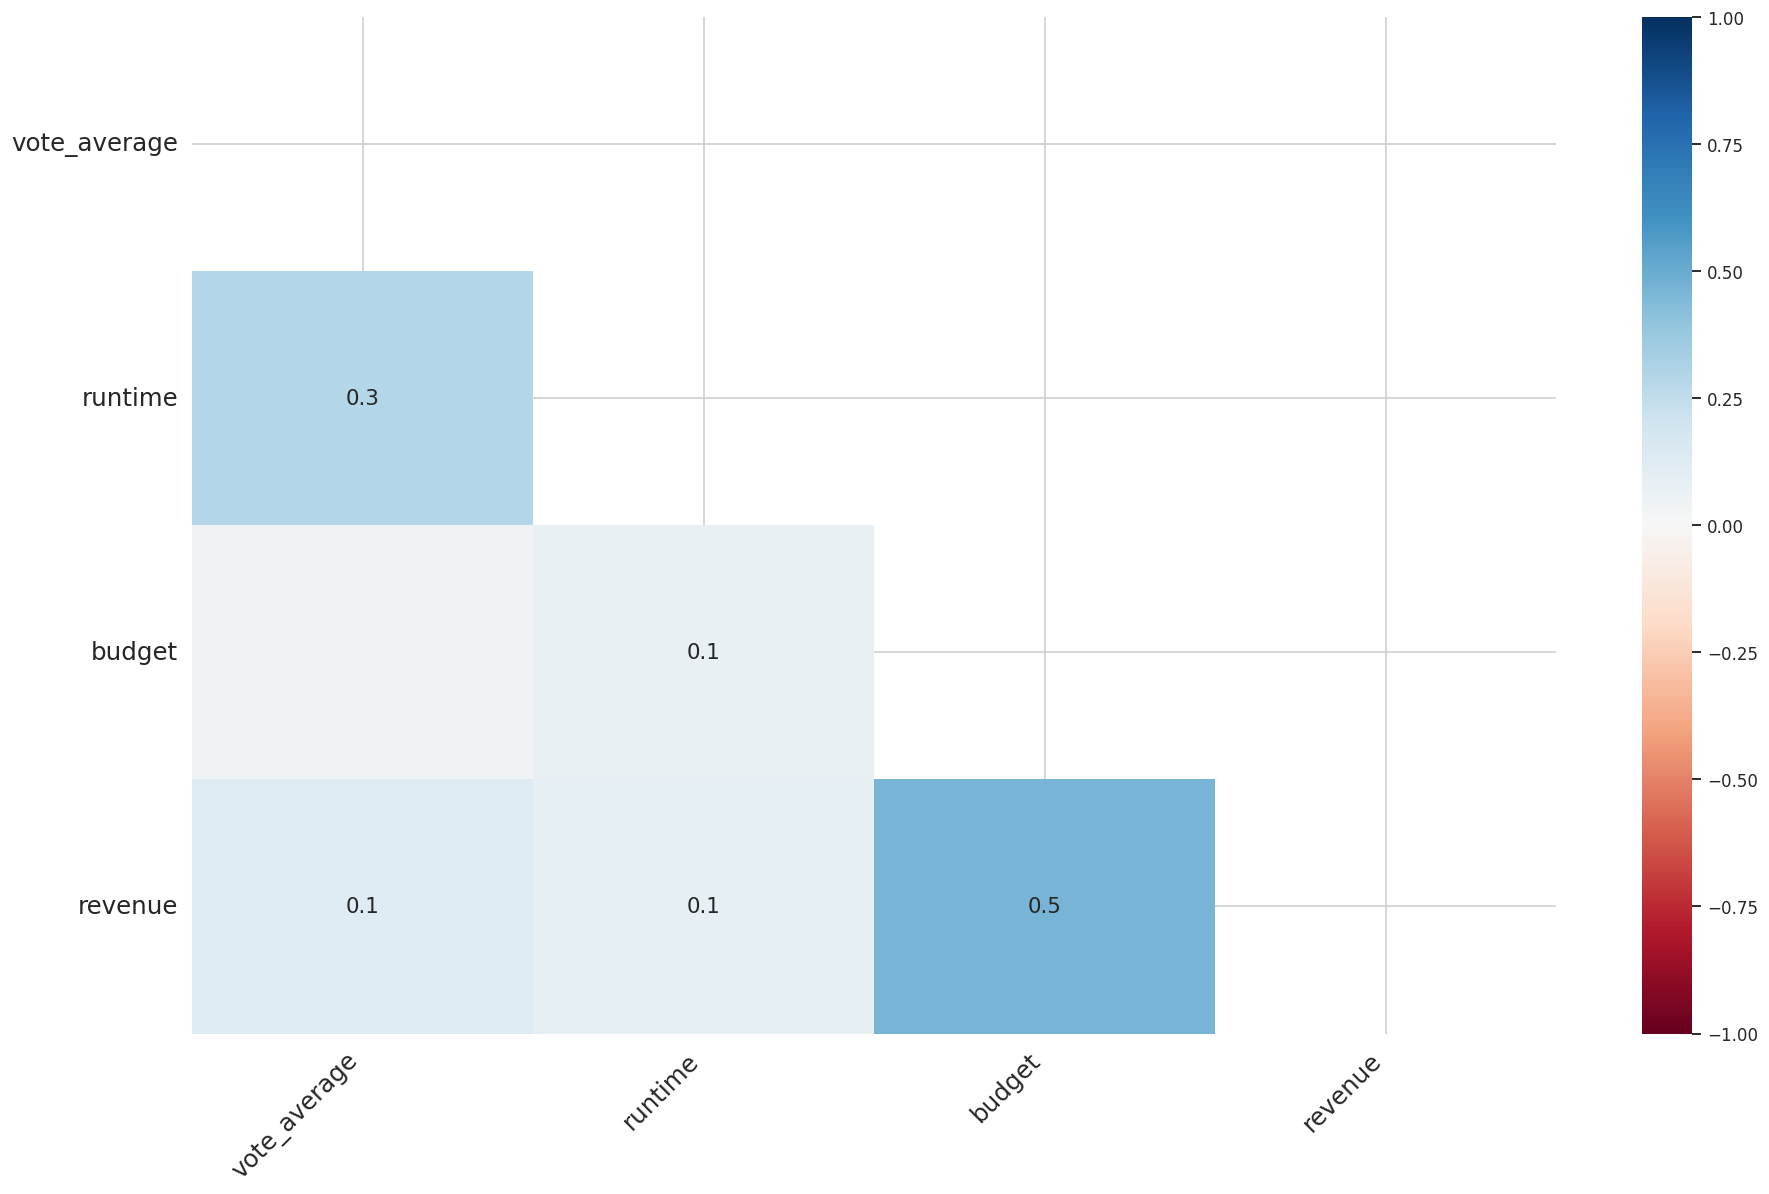

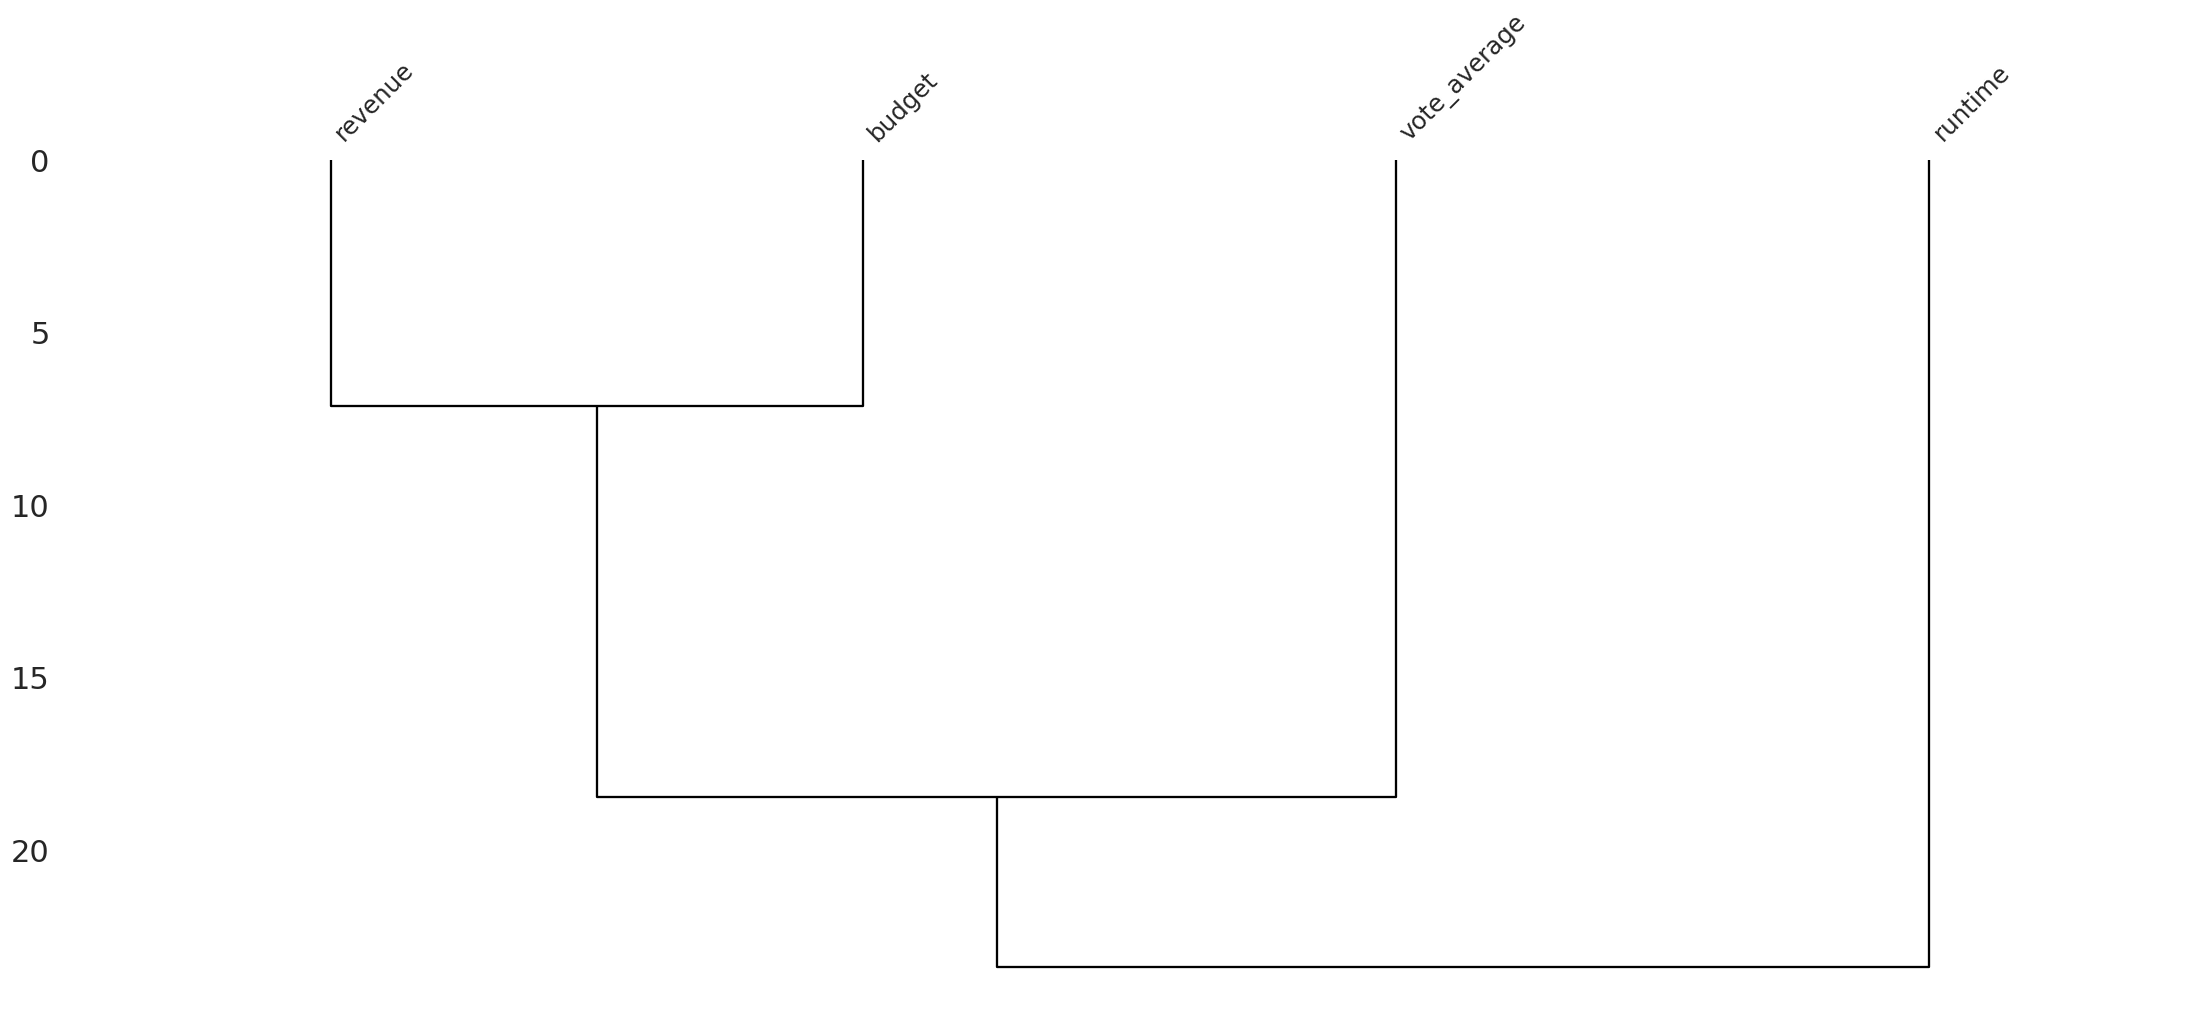

In [ ]:
muestra_msno = df[num_foco].sample(1000, random_state=0)

msno.matrix(muestra_msno)
plt.show()

msno.bar(muestra_msno)
plt.show()

cols_con_nulos = [c for c in num_foco if muestra_msno[c].isna().any()]
msno.heatmap(muestra_msno[cols_con_nulos])
plt.show()

msno.dendrogram(muestra_msno[cols_con_nulos])
plt.show()

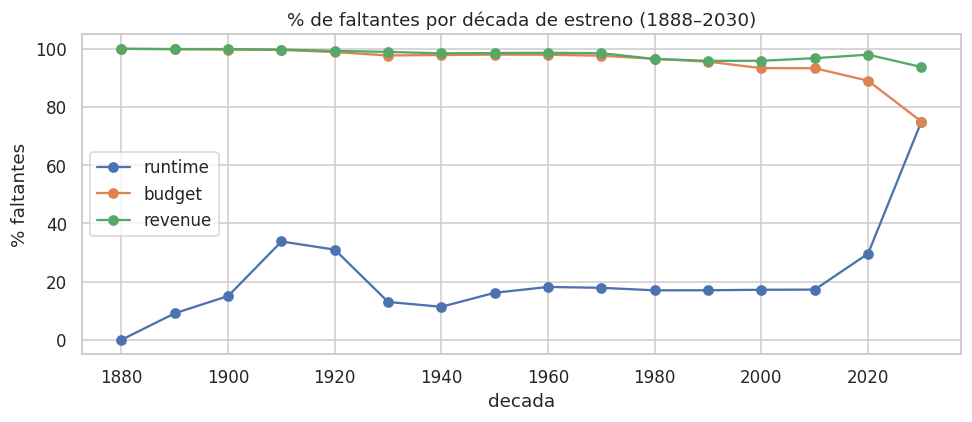

,runtime,budget,revenue
decada,,,
1880.0,0.000000,100.000000,100.000000
1890.0,9.128065,99.863760,99.931880
1900.0,15.047829,99.705666,99.926416
1910.0,33.791698,99.630761,99.745353
1920.0,30.985915,98.880166,99.272685
1930.0,13.008739,97.702871,98.942988
1940.0,11.351900,97.875222,98.442394
1950.0,16.176893,98.004486,98.550808
1960.0,18.171688,97.958371,98.634935


In [ ]:
global df
# % de faltantes por década de estreno (acotado a años plausibles 1888–2030;
# fechas fuera de ese rango son errores/placeholder de release_date, ver nota abajo)
anio = df["release_date"].dt.year
mask_plausible = anio.between(1888, 2030)
decada = (anio[mask_plausible] // 10 * 10)
tabla_decada = (df[mask_plausible].assign(decada=decada)
                  .groupby("decada")[["runtime", "budget", "revenue"]]
                  .apply(lambda g: g.isna().mean() * 100))

tabla_decada.plot(marker="o", figsize=(9, 4))
plt.ylabel("% faltantes")
plt.title("% de faltantes por década de estreno (1888–2030)")
plt.tight_layout()
plt.show()
tabla_decada

In [ ]:
# % de faltantes por género principal (primer género informado por película)
genero_principal = (genre_long.drop_duplicates(subset="id", keep="first")[["id", "genre"]]
                     .rename(columns={"genre": "genero_principal"}))
df_gp = df.merge(genero_principal, on="id", how="left")
tabla_genero = (df_gp.groupby("genero_principal")[["runtime", "budget", "revenue"]]
                     .apply(lambda g: g.isna().mean() * 100)
                     .sort_values("budget"))
tabla_genero

,runtime,budget,revenue
genero_principal,,,
Science Fiction,18.361847,80.993672,95.289431
Horror,19.277677,81.125156,95.993888
Thriller,20.723548,81.751436,94.706614
Adventure,17.417528,83.210241,89.487937
Mystery,22.088693,84.123223,95.125254
Fantasy,21.123110,84.809215,94.773218
Action,20.009955,85.025079,90.933109
Crime,20.826459,88.435578,94.532773
War,18.750000,89.217033,94.333791


**Conclusión provisional sobre faltantes.** Los porcentajes por década, género, estado e idioma sugieren que varios faltantes no son completamente aleatorios; en particular, los financieros parecen estructurales. No se puede descartar MNAR para variables cuya ausencia depende de información no observada.

> TODO: complementar con un modelo indicador-de-faltante (logístico) y una discusión explícita de variables auxiliares para sostener MAR; MNAR requiere análisis de sensibilidad o información externa.

### Outliers cuantitativos

In [ ]:
global df
num_foco = ["vote_average", "runtime", "budget", "revenue", "vote_count", "popularity"]

def contar_outliers(serie):
    s = serie.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf_iqr, lim_sup_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr = ((s < lim_inf_iqr) | (s > lim_sup_iqr)).sum()

    media, desv = s.mean(), s.std()
    lim_inf_3s, lim_sup_3s = media - 3 * desv, media + 3 * desv
    n_3s = ((s < lim_inf_3s) | (s > lim_sup_3s)).sum()

    return pd.Series({
        "n_validos": len(s),
        "pct_outliers_iqr": round(100 * n_iqr / len(s), 2),
        "lim_iqr": (round(lim_inf_iqr, 1), round(lim_sup_iqr, 1)),
        "pct_outliers_3sigma": round(100 * n_3s / len(s), 2),
        "lim_3sigma": (round(lim_inf_3s, 1), round(lim_sup_3s, 1)),
    })

tabla_outliers = pd.DataFrame({c: contar_outliers(df[c]) for c in num_foco}).T
tabla_outliers

,n_validos,pct_outliers_iqr,lim_iqr,pct_outliers_3sigma,lim_3sigma
vote_average,361022,2.43,"(1.7, 10.5)",0.24,"(0.1, 12.2)"
runtime,686974,1.23,"(-105.0, 215.0)",0.62,"(-133.4, 264.6)"
budget,72684,22.51,"(-299625.0, 499775.0)",1.51,"(-63524775.0, 72684246.1)"
revenue,23526,16.35,"(-22279215.2, 37136214.8)",1.56,"(-419611418.5, 496270602.1)"
vote_count,1008691,17.4,"(-1.5, 2.5)",0.38,"(-992.8, 1035.4)"
popularity,1008691,8.72,"(-1.2, 2.1)",0.31,"(-22.9, 25.1)"


In [ ]:
# top-5 registros más extremos por columna (distancia absoluta a la mediana)
def top_extremos(col, n=5):
    s = df[[col, "title"]].dropna(subset=[col])
    mediana = s[col].median()
    s = s.assign(_dist=(s[col] - mediana).abs())
    return s.nlargest(n, "_dist")[["title", col]]

for col in num_foco:
    print(f"\nTop 5 extremos — {col}:")
    print(top_extremos(col).to_string(index=False))


Top 5 extremos — vote_average:
              title  vote_average
       Home Invader           0.0
              MMXII           0.0
             Halali           0.0
Fighting For A City           0.0
        Winter Hunt           0.0

Top 5 extremos — runtime:
                     title  runtime
      Modern Times Forever  14400.0
Svalbard minutt for minutt  13319.0
                 Cinématon  12480.0
              Beijing 2003   9000.0
     The Cure For Insomnia   5220.0

Top 5 extremos — budget:
                                                           title      budget
                                                  In Whose Name? 999999999.0
                      #MagnumOpus Chapter I: The Song of Destiny 999999999.0
The Lord of the Rings: The Return of the King (Extended Edition) 940000000.0
                   ryan gosling der sutter logan pauls tissemand 900000000.0
            Batman v Superman: Dawn of Justice: Ultimate Edition 874362803.0

Top 5 extremos — revenue:
      

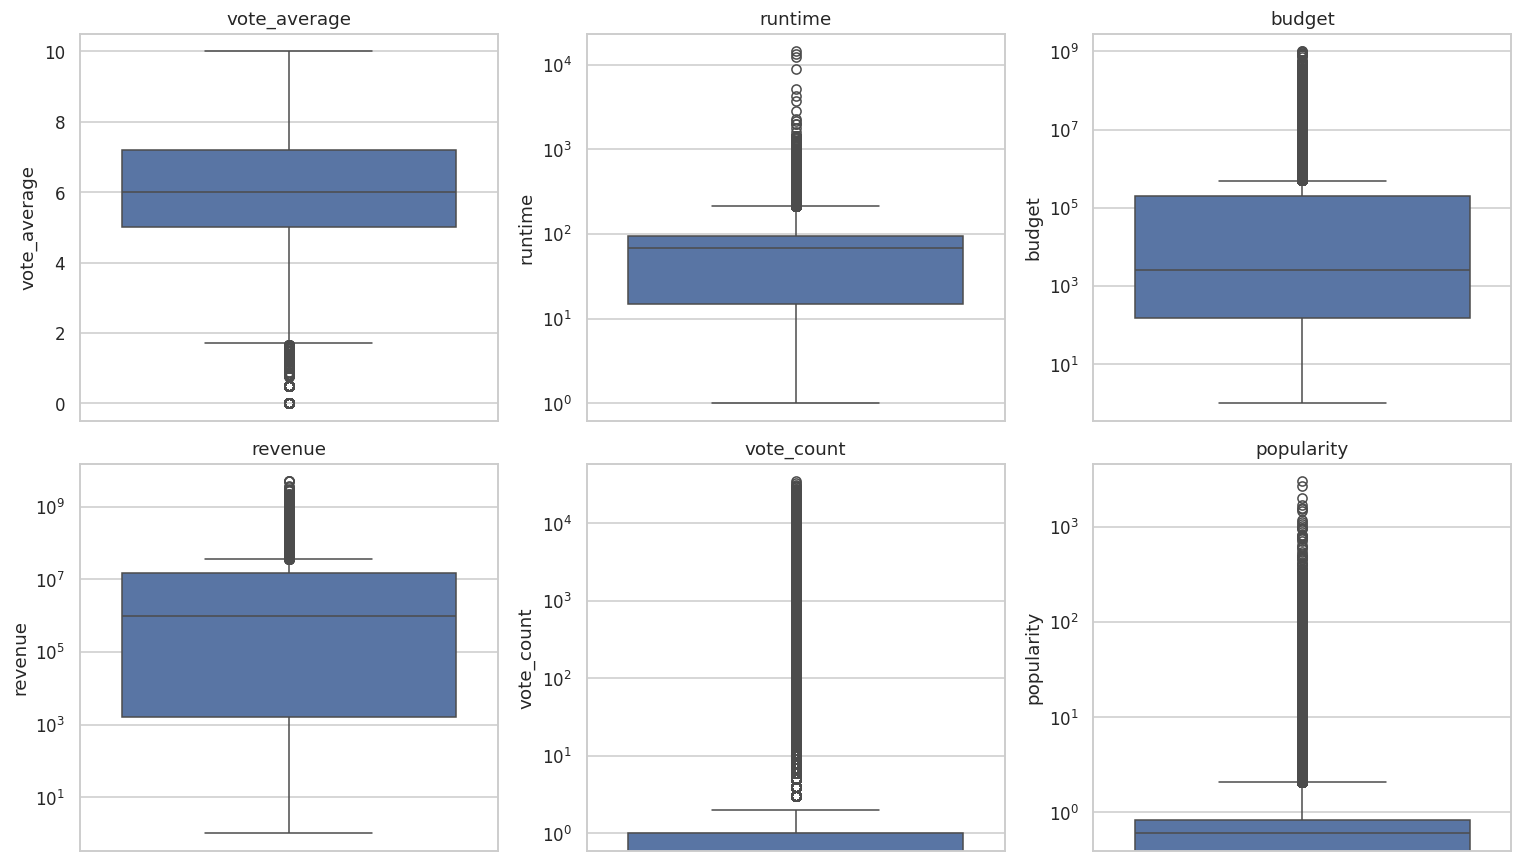

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
log_cols = {"budget", "revenue", "vote_count", "popularity", "runtime"}
for ax, col in zip(axes.flat, num_foco):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
    if col in log_cols:
        ax.set_yscale("log")
plt.tight_layout()
plt.show()

In [ ]:
# Presupuestos imposibles: por encima del mayor presupuesto real documentado (~460M, Avatar 2)
cols_insp = ["title", "release_date", "vote_count", "budget", "revenue", "runtime"]
budget_sosp = (df.loc[df["budget"] > 460_000_000, cols_insp]
                 .sort_values("budget", ascending=False))
print(f"budget > 460M: {len(budget_sosp)} filas")
display(budget_sosp)

budget > 460M: 22 filas


,title,release_date,vote_count,budget,revenue,runtime
434124,In Whose Name?,NaT,0,999999999.0,NaN,NaN
729421,#MagnumOpus Chapter I: The Song of Destiny,2060-07-23,0,999999999.0,NaN,NaN
644812,The Lord of the Rings: The Return of the King ...,NaT,0,940000000.0,1.148000e+08,263.0
500811,ryan gosling der sutter logan pauls tissemand,NaT,0,900000000.0,1.600000e+01,NaN
270728,Batman v Superman: Dawn of Justice: Ultimate E...,2016-06-28,1,874362803.0,2.500000e+08,182.0
801758,ETERNIA: TWILIGHT OF STARS,2027-03-12,0,873000000.0,NaN,NaN
767439,Fifa World Cup 2026 Round of 16 USA vs Belgium,NaT,0,800000000.0,1.300000e+06,90.0
845733,Shadow the Hedgehog,NaT,0,800000000.0,NaN,NaN
509624,Adventures in Bora Bora,2023-08-23,0,800000000.0,3.000000e+09,5.0
862706,M4's The Hobbit Book Edit,2021-12-24,0,700000000.0,2.914620e+09,NaN


In [ ]:
# Recaudaciones imposibles: por encima de la mayor recaudación real documentada (~2.9B, Avatar 2)
revenue_sosp = (df.loc[df["revenue"] > 3_000_000_000, cols_insp]
                  .sort_values("revenue", ascending=False))
print(f"revenue > 3.000M: {len(revenue_sosp)} filas")
display(revenue_sosp)

revenue > 3.000M: 7 filas


,title,release_date,vote_count,budget,revenue,runtime
451271,babben: the movie,NaT,0,100.0,5.000000e+09,999.0
674456,In the Virtual End (Linkin Park HL2 music video),2009-11-02,0,1.0,5.000000e+09,4.0
646874,Han Sur Lesses,2026-04-23,0,500.0,5.000000e+09,NaN
785982,Juliet and Romeo - 1231 ☆*: .｡. o(≧▽≦)o .｡.:*☆...,1800-01-01,0,1.0,5.000000e+09,NaN
278315,Marvel's Spider-Man,2018-09-07,1,100000000.0,3.800000e+09,999.0
872158,Macbeth's Ambition,2026-01-02,0,10000000.0,3.477780e+09,82.0
343894,Red Dead Redemption II,NaT,1,540000000.0,3.100000e+09,NaN


In [ ]:
# Registro de runtime máximo (14400 min = 240 h)
display(df.loc[df["runtime"] >= 14400, ["title", "release_date", "vote_count", "runtime", "overview"]])

,title,release_date,vote_count,runtime,overview
219070,Modern Times Forever,2011-03-23,2,14400.0,"The film shows centuries of decay, compressed ..."


**Interpretación.** IQR y 3σ detectan extremos con criterios distintos: 3σ es sensible a distribuciones pesadamente sesgadas, mientras IQR es más robusto. Los extremos de `runtime`, `budget` y `revenue` deben distinguirse entre errores de carga y casos reales.

> TODO: aplicar y documentar Isolation Forest sobre una muestra/feature set definido. El notebook original no lo implementaba; no se genera aquí para no inventar una decisión analítica.

## 6. Feature engineering y preprocesamiento

La siguiente sección conserva la lógica original: separación train/test, eliminación de fechas imposibles, imputación de `runtime` usando solo train, indicadores de presencia, capping, `log1p`, features temporales y de conteo, discretización, one-hot/multi-hot y escalado. Estas decisiones son apropiadas para reducir asimetría y evitar leakage, pero deben justificarse según el modelo final.

In [ ]:
from pandas.api.types import CategoricalDtype
# Pandas no necesariamente asigna el dtype en forma correcta al importar.
# Conviene revisar cada variable y asignar el tipo de dato correcto.

tmdb_numericas = ['vote_average', 'runtime', 'budget', 'revenue', 'vote_count', 'popularity']

tmdb_cat_nom = ['adult', 'original_language']

# 'status' tiene un orden lógico de ciclo de producción, aunque con ramas (Rumored/Canceled)
# que no encajan en una secuencia lineal estricta. Se documenta la limitación y se define
# el orden solo para las 4 categorías centrales del proceso productivo; las 2 restantes
# quedan igualmente incluidas en el CategoricalDtype pero fuera de la secuencia principal.
tmdb_cat_ord = {
    'status': CategoricalDtype(
        categories=['Rumored', 'Planned', 'In Production', 'Post Production', 'Released', 'Canceled'],
        ordered=False  # se documenta el orden lógico en markdown, pero no se fuerza como ordinal
    ),
}

dtype_map = {col: 'float64' for col in tmdb_numericas}         # numéricas
dtype_map.update({col: 'category' for col in tmdb_cat_nom})    # nominales
dtype_map.update(tmdb_cat_ord)                                 # ordinal candidata (status)

df = df.astype(dtype_map)

df.dtypes

,0
id,int64
title,object
vote_average,float64
vote_count,float64
status,category
release_date,datetime64[ns]
revenue,float64
runtime,float64
adult,category
backdrop_path,object


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
df["popularity_cat"] = pd.cut(df["popularity"], bins=[-np.inf, 1, 10, np.inf],
                              labels=["baja", "media", "alta"])
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42,
                                     stratify=df["popularity_cat"])
print(f"train: {train_df.shape[0]} filas | test: {test_df.shape[0]} filas")
print("Distribución del target (proporción, train):")
print(train_df["popularity_cat"].value_counts(normalize=True).round(3).to_string())

train: 806952 filas | test: 201739 filas
Distribución del target (proporción, train):
popularity_cat
baja     0.792
media    0.193
alta     0.015


In [ ]:
# Errores de carga: valores imposibles (budget/revenue por encima del récord real documentado
# ~460M / ~2.9B) o fecha imposible (año > 2030 o < 1888). Las fechas faltantes (NaT) no se eliminan.
anio_tr = train_df["release_date"].dt.year
anio_te = test_df["release_date"].dt.year
err_train = ((train_df["budget"] > 460_000_000) | (train_df["revenue"] > 3_000_000_000)
             | (anio_tr > 2030) | (anio_tr < 1888))
err_test  = ((test_df["budget"]  > 460_000_000) | (test_df["revenue"]  > 3_000_000_000)
             | (anio_te > 2030) | (anio_te < 1888))
print(f"Errores de carga eliminados -> train: {int(err_train.sum())} | test: {int(err_test.sum())}")
train_df = train_df[~err_train].copy()
test_df  = test_df[~err_test].copy()
print(f"Tamaños tras limpieza -> train: {len(train_df)} | test: {len(test_df)}")

Errores de carga eliminados -> train: 140 | test: 39
Tamaños tras limpieza -> train: 806812 | test: 201700


In [ ]:
runtime_mediana_train = train_df["runtime"].median()

train_df = train_df.copy()
test_df = test_df.copy()
train_df["runtime_imp"] = train_df["runtime"].fillna(runtime_mediana_train)
test_df["runtime_imp"] = test_df["runtime"].fillna(runtime_mediana_train)

print(f"Mediana de runtime aprendida en train: {runtime_mediana_train:.1f} min")
print(f"Nulos runtime train: {train_df['runtime'].isna().sum()} -> {train_df['runtime_imp'].isna().sum()}")
print(f"Nulos runtime test:  {test_df['runtime'].isna().sum()} -> {test_df['runtime_imp'].isna().sum()}")

Mediana de runtime aprendida en train: 69.0 min
Nulos runtime train: 257248 -> 0
Nulos runtime test:  64405 -> 0


In [ ]:
# Indicador de presencia para budget/revenue (faltante estructural): el dato no existe para la
# mayoría del catálogo; conservamos el crudo y marcamos si está informado.
# vote_average NO lleva flag: su faltante ya está codificado por vote_count == 0.
for col in ["budget", "revenue"]:
    train_df[f"tiene_{col}"] = train_df[col].notna().astype(int)
    test_df[f"tiene_{col}"]  = test_df[col].notna().astype(int)
print("Flags creados:", [f"tiene_{c}" for c in ["budget", "revenue"]])
print("Proporción con dato (train):")
print(train_df[["tiene_budget", "tiene_revenue"]].mean().round(3).to_string())

# Las columnas crudas se reemplazan por el indicador: se eliminan.
train_df = train_df.drop(columns=["budget", "revenue"])
test_df  = test_df.drop(columns=["budget", "revenue"])
print("Columnas budget/revenue eliminadas (reemplazadas por indicadores).")

# Indicadores de presencia para URLs (B) y texto libre (C): faltante estructural; conservamos solo
# la marca de si el dato está informado (las columnas originales se dropean en 5.13).
ind_cols = {"homepage": "homepage", "backdrop_path": "backdrop", "poster_path": "poster",
            "overview": "overview", "tagline": "tagline"}
for col, nombre in ind_cols.items():
    train_df[f"tiene_{nombre}"] = train_df[col].notna().astype(int)
    test_df[f"tiene_{nombre}"]  = test_df[col].notna().astype(int)
print("Proporción con dato (train) para URLs y texto:")
print(train_df[["tiene_homepage", "tiene_backdrop", "tiene_poster",
                "tiene_overview", "tiene_tagline"]].mean().round(3).to_string())

Flags creados: ['tiene_budget', 'tiene_revenue']
Proporción con dato (train):
tiene_budget     0.072
tiene_revenue    0.023
Columnas budget/revenue eliminadas (reemplazadas por indicadores).
Proporción con dato (train) para URLs y texto:
tiene_homepage    0.107
tiene_backdrop    0.284
tiene_poster      0.631
tiene_overview    0.760
tiene_tagline     0.162


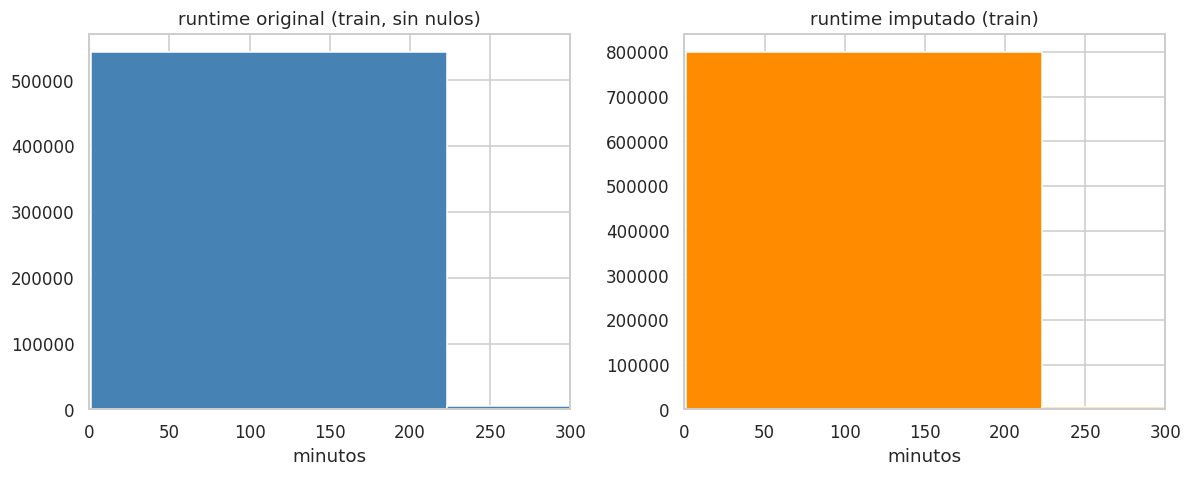

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(train_df["runtime"].dropna(), bins=60, color="steelblue")
axes[0].set_title("runtime original (train, sin nulos)")
axes[1].hist(train_df["runtime_imp"], bins=60, color="darkorange")
axes[1].set_title("runtime imputado (train)")
for ax in axes:
    ax.set_xlim(0, 300)
    ax.set_xlabel("minutos")
plt.tight_layout()
plt.show()

In [ ]:
# Outliers de las continuas que quedan como features: runtime (capping p1-p99) y vote_count (log1p).
# vote_average y popularity se discretizan (no se capean); budget/revenue ya se reemplazaron por indicadores.
lo_rt, hi_rt = train_df["runtime_imp"].quantile([0.01, 0.99])
train_df["runtime_cap"] = train_df["runtime_imp"].clip(lo_rt, hi_rt)
test_df["runtime_cap"]  = test_df["runtime_imp"].clip(lo_rt, hi_rt)

train_df["vote_count_log"] = np.log1p(train_df["vote_count"])
test_df["vote_count_log"]  = np.log1p(test_df["vote_count"])
print(f"runtime: límites de capping (train p1-p99) = [{lo_rt:.0f}, {hi_rt:.0f}] min")
print("vote_count transformado con log1p")

runtime: límites de capping (train p1-p99) = [1, 203] min
vote_count transformado con log1p


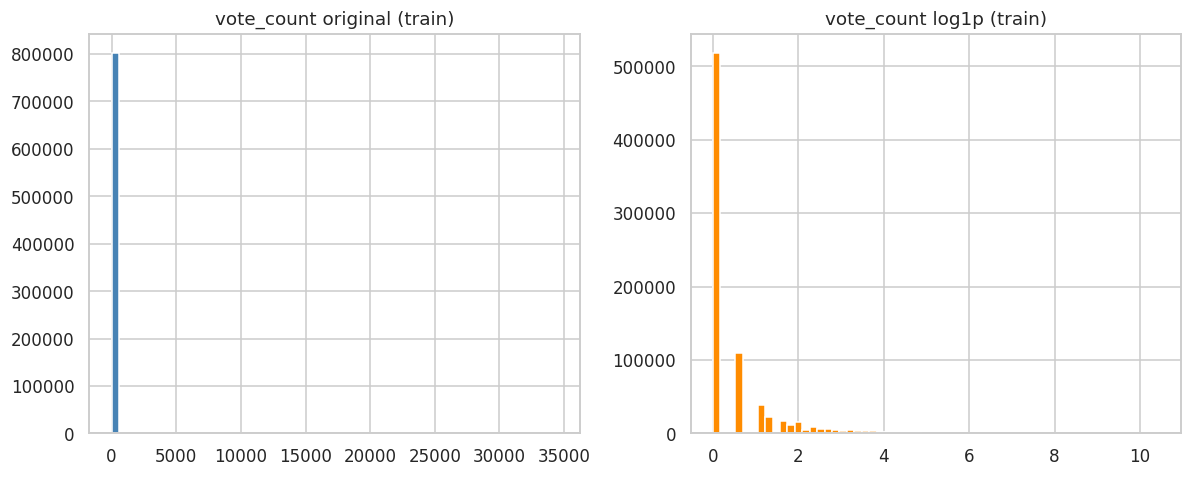

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(train_df["vote_count"].dropna(), bins=60, color="steelblue")
axes[0].set_title("vote_count original (train)")
axes[1].hist(train_df["vote_count_log"].dropna(), bins=60, color="darkorange")
axes[1].set_title("vote_count log1p (train)")
plt.tight_layout()
plt.show()

In [ ]:
for d in (train_df, test_df):
    d["anio"] = d["release_date"].dt.year
    d["decada"] = (d["anio"] // 10 * 10)
    d["mes"] = d["release_date"].dt.month
    d["n_generos"] = d["genres"].fillna("").apply(lambda s: len([g for g in s.split(", ") if g]))
    # Largo de texto (A, C): 0 cuando el campo está vacío
    d["title_length"] = d["title"].fillna("").str.len()
    d["len_overview"] = d["overview"].fillna("").str.len()
    d["len_tagline"] = d["tagline"].fillna("").str.len()
    # Conteo de ítems en las multivaluadas (F) + indicador de presencia
    for col, nombre in [("spoken_languages", "idiomas"), ("production_countries", "paises"),
                        ("production_companies", "companias"), ("keywords", "keywords")]:
        d[f"n_{nombre}"] = d[col].fillna("").apply(lambda s: len([t for t in s.split(", ") if t]))
        d[f"tiene_{nombre}"] = (d[f"n_{nombre}"] > 0).astype(int)

feats_show = ["anio", "decada", "mes", "n_generos", "title_length", "len_overview",
              "len_tagline", "n_idiomas", "n_paises", "n_companias", "n_keywords"]
print("Features nuevos (train):")
print(train_df[feats_show].describe().round(2).to_string())

Features nuevos (train):
            anio     decada        mes  n_generos  title_length  len_overview  len_tagline  n_idiomas   n_paises  n_companias  n_keywords
count  575216.00  575216.00  575216.00  806812.00     806812.00     806812.00    806812.00  806812.00  806812.00    806812.00   806812.00
mean     2002.46    1997.92       6.02       0.89         20.16        200.11         7.14       0.60       0.56         0.65        0.95
std        26.27      26.42       3.76       1.02         14.66        212.26        21.11       0.65       0.74         1.04        2.53
min      1888.00    1880.00       1.00       0.00          0.00          0.00         0.00       0.00       0.00         0.00        0.00
25%      1993.00    1990.00       2.00       0.00         11.00         14.00         0.00       0.00       0.00         0.00        0.00
50%      2013.00    2010.00       6.00       1.00         17.00        144.00         0.00       1.00       1.00         0.00        0.00
75%      

In [ ]:
# qcut en train (igual frecuencia); los cortes se reutilizan en test (transform).
_, bins_va = pd.qcut(train_df["vote_average"].dropna(), q=4, retbins=True, duplicates="drop")
bins_va = bins_va.copy()
bins_va[0], bins_va[-1] = -np.inf, np.inf
labels_va = ["bajo", "medio-bajo", "medio-alto", "alto"][: len(bins_va) - 1]

for d in (train_df, test_df):
    cat = pd.cut(d["vote_average"], bins=bins_va, labels=labels_va, include_lowest=True)
    d["vote_average_cat"] = cat.cat.add_categories("sin votos").fillna("sin votos")

print("Distribución de vote_average_cat (train):")
print(train_df["vote_average_cat"].value_counts().to_string())

Distribución de vote_average_cat (train):
vote_average_cat
sin votos     518200
bajo           82475
alto           71220
medio-alto     70200
medio-bajo     64717


In [ ]:
genre_multihot = df.set_index("id")["genres"].str.get_dummies(", ").add_prefix("gen_")
print("shape multi-hot:", genre_multihot.shape)
genre_multihot.head()

shape multi-hot: (1008691, 19)


,gen_Action,gen_Adventure,gen_Animation,gen_Comedy,gen_Crime,gen_Documentary,gen_Drama,gen_Family,gen_Fantasy,gen_History,gen_Horror,gen_Music,gen_Mystery,gen_Romance,gen_Science Fiction,gen_TV Movie,gen_Thriller,gen_War,gen_Western
id,,,,,,,,,,,,,,,,,,,
27205,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
157336,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
155,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0
19995,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
24428,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [ ]:
genero_principal_ohe = (df[["id"]].merge(
        genre_long.drop_duplicates(subset="id", keep="first")[["id", "genre"]],
        on="id", how="left")
    .rename(columns={"genre": "genero_principal"}))
genero_principal_ohe["genero_principal"] = genero_principal_ohe["genero_principal"].fillna("SIN_GÉNERO")

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_matrix = ohe.fit_transform(genero_principal_ohe[["genero_principal"]])
print("shape OneHot género principal:", ohe_matrix.shape, "| categorías:", len(ohe.categories_[0]))
print("¿incluye SIN_GÉNERO?:", "SIN_GÉNERO" in ohe.categories_[0])

shape OneHot género principal: (1008691, 20) | categorías: 20
¿incluye SIN_GÉNERO?: True


In [ ]:
# status -> 3 categorías (Released, In Production, resto -> "otros"); adult -> entero.
principales = ["Released", "In Production"]
for d in (train_df, test_df):
    s = d["status"].astype(str)
    d["status_3"] = s.where(s.isin(principales), "otros")
    d["adult"] = d["adult"].astype(int)

ohe_status = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_status.fit(train_df[["status_3"]])
cols_status = [f"status_{c.lower().replace(' ', '_')}" for c in ohe_status.categories_[0]]
for d in (train_df, test_df):
    d[cols_status] = ohe_status.transform(d[["status_3"]]).astype(int)
print("status ->", cols_status)
print(train_df[cols_status].sum().to_string())

status -> ['status_in_production', 'status_released', 'status_otros']
status_in_production     18729
status_released         768200
status_otros             19883


In [ ]:
# original_language: top-10 aprendido en TRAIN, resto -> "otros" (fit train / transform test).
lang_str_tr = train_df["original_language"].astype(str)
top10_lang = lang_str_tr.value_counts().head(10).index.tolist()
for d in (train_df, test_df):
    s = d["original_language"].astype(str)
    d["lang_top"] = s.where(s.isin(top10_lang), "otros")

ohe_lang = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_lang.fit(train_df[["lang_top"]])
cols_lang = [f"lang_{c}" for c in ohe_lang.categories_[0]]
for d in (train_df, test_df):
    d[cols_lang] = ohe_lang.transform(d[["lang_top"]]).astype(int)
print("top-10 idiomas (train):", top10_lang)
print("original_language ->", len(cols_lang), "columnas OHE:", cols_lang)

top-10 idiomas (train): ['en', 'fr', 'es', 'ja', 'de', 'zh', 'pt', 'it', 'ru', 'ko']
original_language -> 11 columnas OHE: ['lang_de', 'lang_en', 'lang_es', 'lang_fr', 'lang_it', 'lang_ja', 'lang_ko', 'lang_otros', 'lang_pt', 'lang_ru', 'lang_zh']


In [ ]:
# Multi-hot de las 15 categorías más frecuentes (fit en TRAIN) para las multivaluadas.
# El resto se agrupa en "*_otros"; su presencia ya está contada en n_*.
def _top_tokens(col, k=15):
    s = train_df[col].dropna().str.split(", ").explode().str.strip()
    return s[s != ""].value_counts().head(k).index.tolist()

multi_cfg = [("spoken_languages", "lang_hab", "idiomas"),
             ("production_countries", "pais", "paises"),
             ("production_companies", "comp", "companias")]

for col, pref, ncol in multi_cfg:
    top15 = _top_tokens(col)
    top_set = set(top15)
    for d in (train_df, test_df):
        ex = d[col].fillna("").str.split(", ").explode().str.strip()
        ex_top = ex[ex.isin(top_set)]
        if len(ex_top):
            ct = pd.crosstab(ex_top.index, ex_top).reindex(index=d.index, columns=top15, fill_value=0)
        else:
            ct = pd.DataFrame(0, index=d.index, columns=top15)
        mh = (ct > 0).astype(int)
        mh.columns = [f"{pref}_{c}" for c in top15]
        d[list(mh.columns)] = mh.values
        d[f"{pref}_otros"] = (d[f"n_{ncol}"].values - ct.sum(axis=1).values > 0).astype(int)
    print(f"{col} -> multi-hot top-15 (prefijo {pref}_) + {pref}_otros | top: {top15[:5]}...")

spoken_languages -> multi-hot top-15 (prefijo lang_hab_) + lang_hab_otros | top: ['English', 'French', 'Spanish', 'Japanese', 'German']...
production_countries -> multi-hot top-15 (prefijo pais_) + pais_otros | top: ['United States of America', 'France', 'Japan', 'United Kingdom', 'Germany']...
production_companies -> multi-hot top-15 (prefijo comp_) + comp_otros | top: ['Warner Bros. Pictures', 'Metro-Goldwyn-Mayer', 'BBC', 'ARTE', 'Columbia Pictures']...


In [ ]:
num_scale = ["runtime_cap", "vote_count_log", "n_generos", "anio",
             "title_length", "len_overview", "len_tagline",
             "n_idiomas", "n_paises", "n_companias", "n_keywords"]
med = train_df[num_scale].median()
Xtr = train_df[num_scale].fillna(med)
Xte = test_df[num_scale].fillna(med)

ss = StandardScaler().fit(Xtr)
tr_ss = pd.DataFrame(ss.transform(Xtr), columns=num_scale, index=Xtr.index)
te_ss = pd.DataFrame(ss.transform(Xte), columns=num_scale, index=Xte.index)

print("Z-score (train) -> media/desvío:")
print(tr_ss.describe().loc[["mean", "std"]].round(2).to_string())

p_orig = Xtr["runtime_cap"].corr(Xtr["vote_count_log"])
p_scaled = tr_ss["runtime_cap"].corr(tr_ss["vote_count_log"])
print(f"\nPearson runtime_cap-vote_count_log: original {p_orig:.4f} | tras Z-score {p_scaled:.4f} (invariante)")

Z-score (train) -> media/desvío:
      runtime_cap  vote_count_log  n_generos  anio  title_length  len_overview  len_tagline  n_idiomas  n_paises  n_companias  n_keywords
mean          0.0            -0.0       -0.0  -0.0          -0.0          -0.0          0.0       -0.0      -0.0          0.0         0.0
std           1.0             1.0        1.0   1.0           1.0           1.0          1.0        1.0       1.0          1.0         1.0

Pearson runtime_cap-vote_count_log: original 0.2515 | tras Z-score 0.2515 (invariante)


**Justificación teórica breve.** `log1p` comprime colas derechas y preserva el cero; el capping p1–p99 limita la influencia de extremos sin eliminar filas; la imputación por mediana es robusta y se ajusta solo en train; one-hot/multi-hot representa categorías nominales sin imponer orden; el Z-score centra y escala variables para métodos sensibles a magnitud (por ejemplo KNN). Estas transformaciones no vuelven normal a una variable por sí mismas.

> TODO: documentar con mayor precisión por qué se conservan/eliminan `revenue` y `budget` según el objetivo predictivo, y evaluar leakage si `popularity` es target.

### Desbalance del target exploratorio

Entropía de Shannon del target (train): 0.818 (máx 1.585)
Distribución original (train): {'baja': 638716, 'media': 155670, 'alta': 12426}
Tras SMOTE (solo train): {'baja': 638716, 'media': 638716, 'alta': 638716}
Tras undersampling (solo train): {'baja': 12426, 'media': 12426, 'alta': 12426}


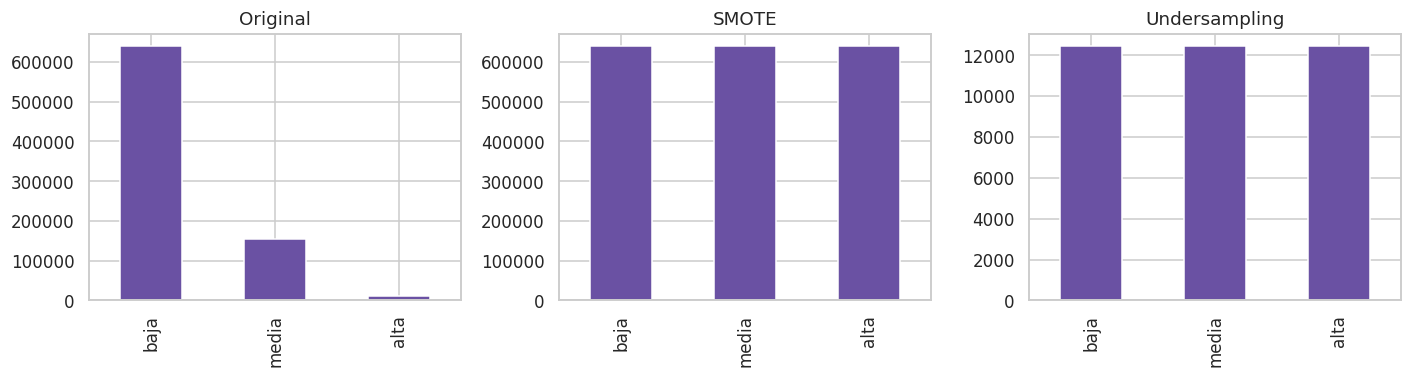

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

feat_bal = ["runtime_cap", "vote_count_log", "n_generos", "anio", "tiene_budget", "tiene_revenue"]
Xb = train_df[feat_bal].fillna(train_df[feat_bal].median())
yb = train_df["popularity_cat"]

probs = yb.value_counts(normalize=True)
H = -(probs * np.log2(probs)).sum()
print(f"Entropía de Shannon del target (train): {H:.3f} (máx {np.log2(len(probs)):.3f})")
print("Distribución original (train):", yb.value_counts().to_dict())

X_sm, y_sm = SMOTE(random_state=42).fit_resample(Xb, yb)
X_us, y_us = RandomUnderSampler(random_state=42).fit_resample(Xb, yb)
print("Tras SMOTE (solo train):", y_sm.value_counts().to_dict())
print("Tras undersampling (solo train):", y_us.value_counts().to_dict())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (titulo, serie) in zip(axes, [("Original", yb), ("SMOTE", y_sm), ("Undersampling", y_us)]):
    serie.value_counts().reindex(["baja", "media", "alta"]).plot.bar(ax=ax, color="#6a51a3")
    ax.set_title(titulo)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

### Dataset final

In [ ]:
# Se eliminan las columnas originales ya procesadas (y las intermedias auxiliares status_3/lang_top).
cols_drop = [
    "title", "original_title", "imdb_id",              # A
    "homepage", "backdrop_path", "poster_path",        # B
    "overview", "tagline",                             # C
    "status", "status_3",                              # D
    "original_language", "lang_top",                   # E
    "spoken_languages", "production_countries",        # F
    "production_companies", "keywords",
    "runtime", "runtime_imp", "vote_count", "genres",  # crudas ya reemplazadas por versiones tratadas
]
train_final = train_df.drop(columns=[c for c in cols_drop if c in train_df.columns])
test_final  = test_df.drop(columns=[c for c in cols_drop if c in test_df.columns])

print(f"Dataset final -> train: {train_final.shape} | test: {test_final.shape}")
obj_rest = [c for c in train_final.columns if train_final[c].dtype == "object"]
print("Columnas object restantes (deberían ser ninguna):", obj_rest or "ninguna")
print("Columnas del dataset final (", len(train_final.columns), "):")
print(sorted(train_final.columns.tolist()))

Dataset final -> train: (806812, 96) | test: (201700, 96)
Columnas object restantes (deberían ser ninguna): ['original_language_bin', 'status_bin']
Columnas del dataset final ( 96 ):
['adult', 'anio', 'año', 'comp_20th Century Fox', 'comp_ARD', 'comp_ARTE', 'comp_BBC', 'comp_Canal+', 'comp_Columbia Pictures', 'comp_Evil Angel', 'comp_Metro-Goldwyn-Mayer', 'comp_ONF | NFB', 'comp_Paramount', 'comp_TOHO', 'comp_Toei Company', 'comp_Universal Pictures', 'comp_Warner Bros. Pictures', 'comp_ZDF', 'comp_otros', 'decada', 'id', 'lang_de', 'lang_en', 'lang_es', 'lang_fr', 'lang_hab_Arabic', 'lang_hab_Czech', 'lang_hab_English', 'lang_hab_French', 'lang_hab_German', 'lang_hab_Hindi', 'lang_hab_Italian', 'lang_hab_Japanese', 'lang_hab_Korean', 'lang_hab_Mandarin', 'lang_hab_No Language', 'lang_hab_Portuguese', 'lang_hab_Russian', 'lang_hab_Spanish', 'lang_hab_Swedish', 'lang_hab_otros', 'lang_it', 'lang_ja', 'lang_ko', 'lang_otros', 'lang_pt', 'lang_ru', 'lang_zh', 'len_overview', 'len_tagline',

## 7. Conclusiones finales

- `budget` y `revenue` tienen faltantes estructurales muy altos; convertir centinelas a `NaN` y usar indicadores de presencia evita imputaciones engañosas.
- `budget`, `revenue`, `vote_count` y `popularity` son fuertemente asimétricos y presentan outliers; las transformaciones robustas y las escalas logarítmicas son preferibles a suponer normalidad.
- `vote_average` es acotada y menos asimétrica; sus relaciones con otras variables deben interpretarse con tamaños de efecto, no solo p-valores.
- Géneros, idiomas y productoras son variables multivaluadas: se analizaron en formato largo y luego se codificaron con multi-hot/top-k.
- La separación train/test precede a la imputación, discretización y selección de categorías para reducir leakage.
- Las asociaciones observadas son estadísticas, no causales. La cobertura temporal y la ausencia de datos financieros limitan la generalización.

### Pendientes académicos
1. Pruebas formales de normalidad con muestreo y discusión de potencia estadística.
2. Análisis de sensibilidad MCAR/MAR/MNAR y un indicador-de-faltante modelado.
3. Isolation Forest y comparación con IQR/Z-score, con criterio explícito de decisión.
4. Storytelling cuantitativo más específico debajo de cada figura (efecto, n válido y limitación).
5. Justificación del target y control de leakage en un pipeline reproducible de modelado.